# Feature/filter analysis

Analyzes how individual query filters affect accuracy across technologies.
For each filter column in the benchmark config, computes the mean accuracy
when that filter is present vs absent, and shows a per-filter heatmap.

In [11]:
import glob as glob_module

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

%config InlineBackend.figure_format='retina'

FONTSIZE = 12

In [ ]:
import os
import yaml

# Load benchmark config
with open("../config.yaml") as _f:
    _config = yaml.safe_load(_f)

configs = pd.read_csv(f"../{_config['benchmark_csv']}")
configs = configs[pd.to_numeric(configs["query_id"], errors="coerce").notna()]
configs["query_id"] = configs["query_id"].astype(int)

rerun = True

AGENT_REGISTRY = [
    ("Claude", "../results/claude", "claude_"),
    ("Biomni", "../results/biomni", "biomni_"),
    ("Edison", "../results/edison_analysis", ""),
    ("GPT", "../results/gpt", "gpt_"),
]

AGENT_BASE_COLORS = {
    "Claude": "#f3f3f3",
    "Biomni": "#c2c2c2",
    "Edison": "#9b9b9b",
    "GPT": "#7c7c7c",
    "gget virus": "#EE6C4D",
}


def discover_sources(rerun=True, file_type="summary"):
    ext = ".csv" if file_type == "summary" else ".json"
    rerun_sfx = "_rerun_*" if rerun else ""
    sources = {}
    for agent, base_dir, prefix in AGENT_REGISTRY:
        if not os.path.isdir(base_dir):
            continue
        subdirs = sorted(
            e for e in os.listdir(base_dir)
            if os.path.isdir(os.path.join(base_dir, e)) and e != "pilot" and not e.startswith(".")
        )
        for model in subdirs:
            label = f"{agent} ({model})"
            d = f"{base_dir}/{model}"
            sources[label] = (f"{d}/{prefix}benchmark_{file_type}_*{rerun_sfx}{ext}", "_gv_")
            sources[f"{label} + gget"] = (f"{d}/{prefix}benchmark_{file_type}_gv_*{rerun_sfx}{ext}", None)
    gget_dir = "../results/gget_virus"
    if os.path.isdir(gget_dir):
        sources["gget virus"] = (f"{gget_dir}/gget_direct_benchmark_{file_type}_*{rerun_sfx}{ext}", None)
    return sources


def get_agent_base(tech_name):
    if tech_name == "gget virus":
        return "gget virus"
    base = tech_name.split(" (")[0]
    if base.endswith(" + gget"):
        base = base[:-7]
    return base


SOURCES = discover_sources(rerun=rerun, file_type="summary")
TECHNOLOGIES = list(SOURCES.keys())

COLORS = {}
for t in TECHNOLOGIES:
    base = get_agent_base(t)
    COLORS[t] = AGENT_BASE_COLORS.get(base, "#000000")

print(f"Loaded {len(configs)} queries from benchmark config")

In [13]:
def load_csv(pattern, exclude=None):
    files = sorted(glob_module.glob(pattern))
    if exclude:
        files = [f for f in files if exclude not in f]
    if not files:
        return pd.DataFrame()
    return pd.read_csv(files[-1])

def accuracy_per_case(expected, runs):
    """Fraction of runs that exactly match expected, ignoring NaN runs."""
    matches = runs == expected[:, None]
    not_nan = ~np.isnan(runs)
    fraction_match = np.full(runs.shape[0], np.nan)
    for i in range(runs.shape[0]):
        valid = not_nan[i]
        n_valid = np.sum(valid)
        if n_valid == 0:
            fraction_match[i] = np.nan
        else:
            fraction_match[i] = np.sum(matches[i][valid]) / n_valid
    return fraction_match

# Load results and compute per-query accuracy for each technology
# Store as {tech_name: {query_id: accuracy}}
tech_accuracy = {}
for name in TECHNOLOGIES:
    pattern, exclude = SOURCES[name]
    df = load_csv(pattern, exclude)
    if df.empty:
        alt_pattern = pattern.replace("_rerun_", "_")
        df = load_csv(alt_pattern, exclude)
        if not df.empty:
            print(f"  [INFO] Rerun files not found for {name}. Falling back to non-rerun files.")
    if df.empty:
        print(f"  WARNING: No data for {name}")
        continue

    query_ids = sorted(df["query_id"].unique())
    n_runs = df["run_number"].nunique()
    expected = np.full(len(query_ids), np.nan)
    runs = np.full((len(query_ids), n_runs), np.nan)

    for i, qid in enumerate(query_ids):
        group = df[df["query_id"] == qid].sort_values("run_number")
        expected[i] = group["expected_count"].iloc[0]
        for _, row in group.iterrows():
            j = int(row["run_number"]) - 1
            error_val = row.get("error", "")
            has_error = error_val is not None and not pd.isnull(error_val) and str(error_val).strip() != ""
            if has_error:
                continue
            retrieved = row.get("retrieved_count", np.nan)
            if pd.isnull(retrieved):
                continue  # treat None as NaN (NONE_TREATED_AS_ZERO=False)
            runs[i, j] = retrieved

    acc = accuracy_per_case(expected, runs)
    tech_accuracy[name] = dict(zip(query_ids, acc))

print(f"Loaded accuracy for {len(tech_accuracy)} technologies")

Loaded accuracy for 9 technologies


## Accuracy by filter presence

For each filter column, compute the mean accuracy across all queries where that filter
is active (non-empty) vs inactive (empty). This shows which filters are associated with
lower accuracy.

In [14]:
# Filter columns to analyze (exclude query_id, expected_count, pathogen, tax_id)
FILTER_COLS = [
    "host", "nuc_completeness", "geographic_location", "submitter_country",
    "min_collection_date", "max_collection_date", "min_release_date", "max_release_date",
    "min_seq_length", "max_seq_length", "max_ambiguous_chars", "lineage",
    "source_database", "segment", "vaccine_strain", "lab_passaged",
    "is_alphainfluenza", "is_sars_cov2", "is_accession",
]

# Only keep filters that are used in at least some queries
active_filters = [col for col in FILTER_COLS if configs[col].notna().sum() > 0]

# For each filter, determine which query IDs have it active
filter_qids = {}
for col in active_filters:
    filter_qids[col] = set(configs[configs[col].notna()]["query_id"].tolist())

# LLM grouping (same as create_figures.ipynb)
llm_bases = [name for name in TECHNOLOGIES if "gget" not in name]
llm_gget = [name + " + gget" for name in llm_bases]
gget_virus_name = "gget virus"
left_tech = llm_bases
right_tech = llm_gget + [gget_virus_name]
n_left = len(left_tech)
n_right = len(right_tech)

# Compute mean accuracy per filter x technology
# For "present": mean accuracy across queries where filter is active
filter_acc_present = {}  # {tech: [acc_per_filter]}
filter_acc_absent = {}   # {tech: [acc_per_filter]}

for name in TECHNOLOGIES:
    qid_acc = tech_accuracy.get(name, {})
    present_vals = []
    absent_vals = []
    for col in active_filters:
        qids_with = filter_qids[col]
        acc_with = [qid_acc[qid] for qid in qid_acc if qid in qids_with]
        acc_without = [qid_acc[qid] for qid in qid_acc if qid not in qids_with]
        present_vals.append(np.nanmean(acc_with) if acc_with else np.nan)
        absent_vals.append(np.nanmean(acc_without) if acc_without else np.nan)
    filter_acc_present[name] = present_vals
    filter_acc_absent[name] = absent_vals

# Also compute number of queries per filter
n_queries_per_filter = [len(filter_qids[col]) for col in active_filters]

print(f"Analyzing {len(active_filters)} active filters")
for col, n in zip(active_filters, n_queries_per_filter):
    print(f"  {col}: {n} queries")

Analyzing 19 active filters
  host: 32 queries
  nuc_completeness: 38 queries
  geographic_location: 69 queries
  submitter_country: 11 queries
  min_collection_date: 69 queries
  max_collection_date: 66 queries
  min_release_date: 87 queries
  max_release_date: 117 queries
  min_seq_length: 69 queries
  max_seq_length: 32 queries
  max_ambiguous_chars: 74 queries
  lineage: 1 queries
  source_database: 10 queries
  segment: 5 queries
  vaccine_strain: 4 queries
  lab_passaged: 15 queries
  is_alphainfluenza: 8 queries
  is_sars_cov2: 1 queries
  is_accession: 3 queries


/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_82368/3166000141.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])


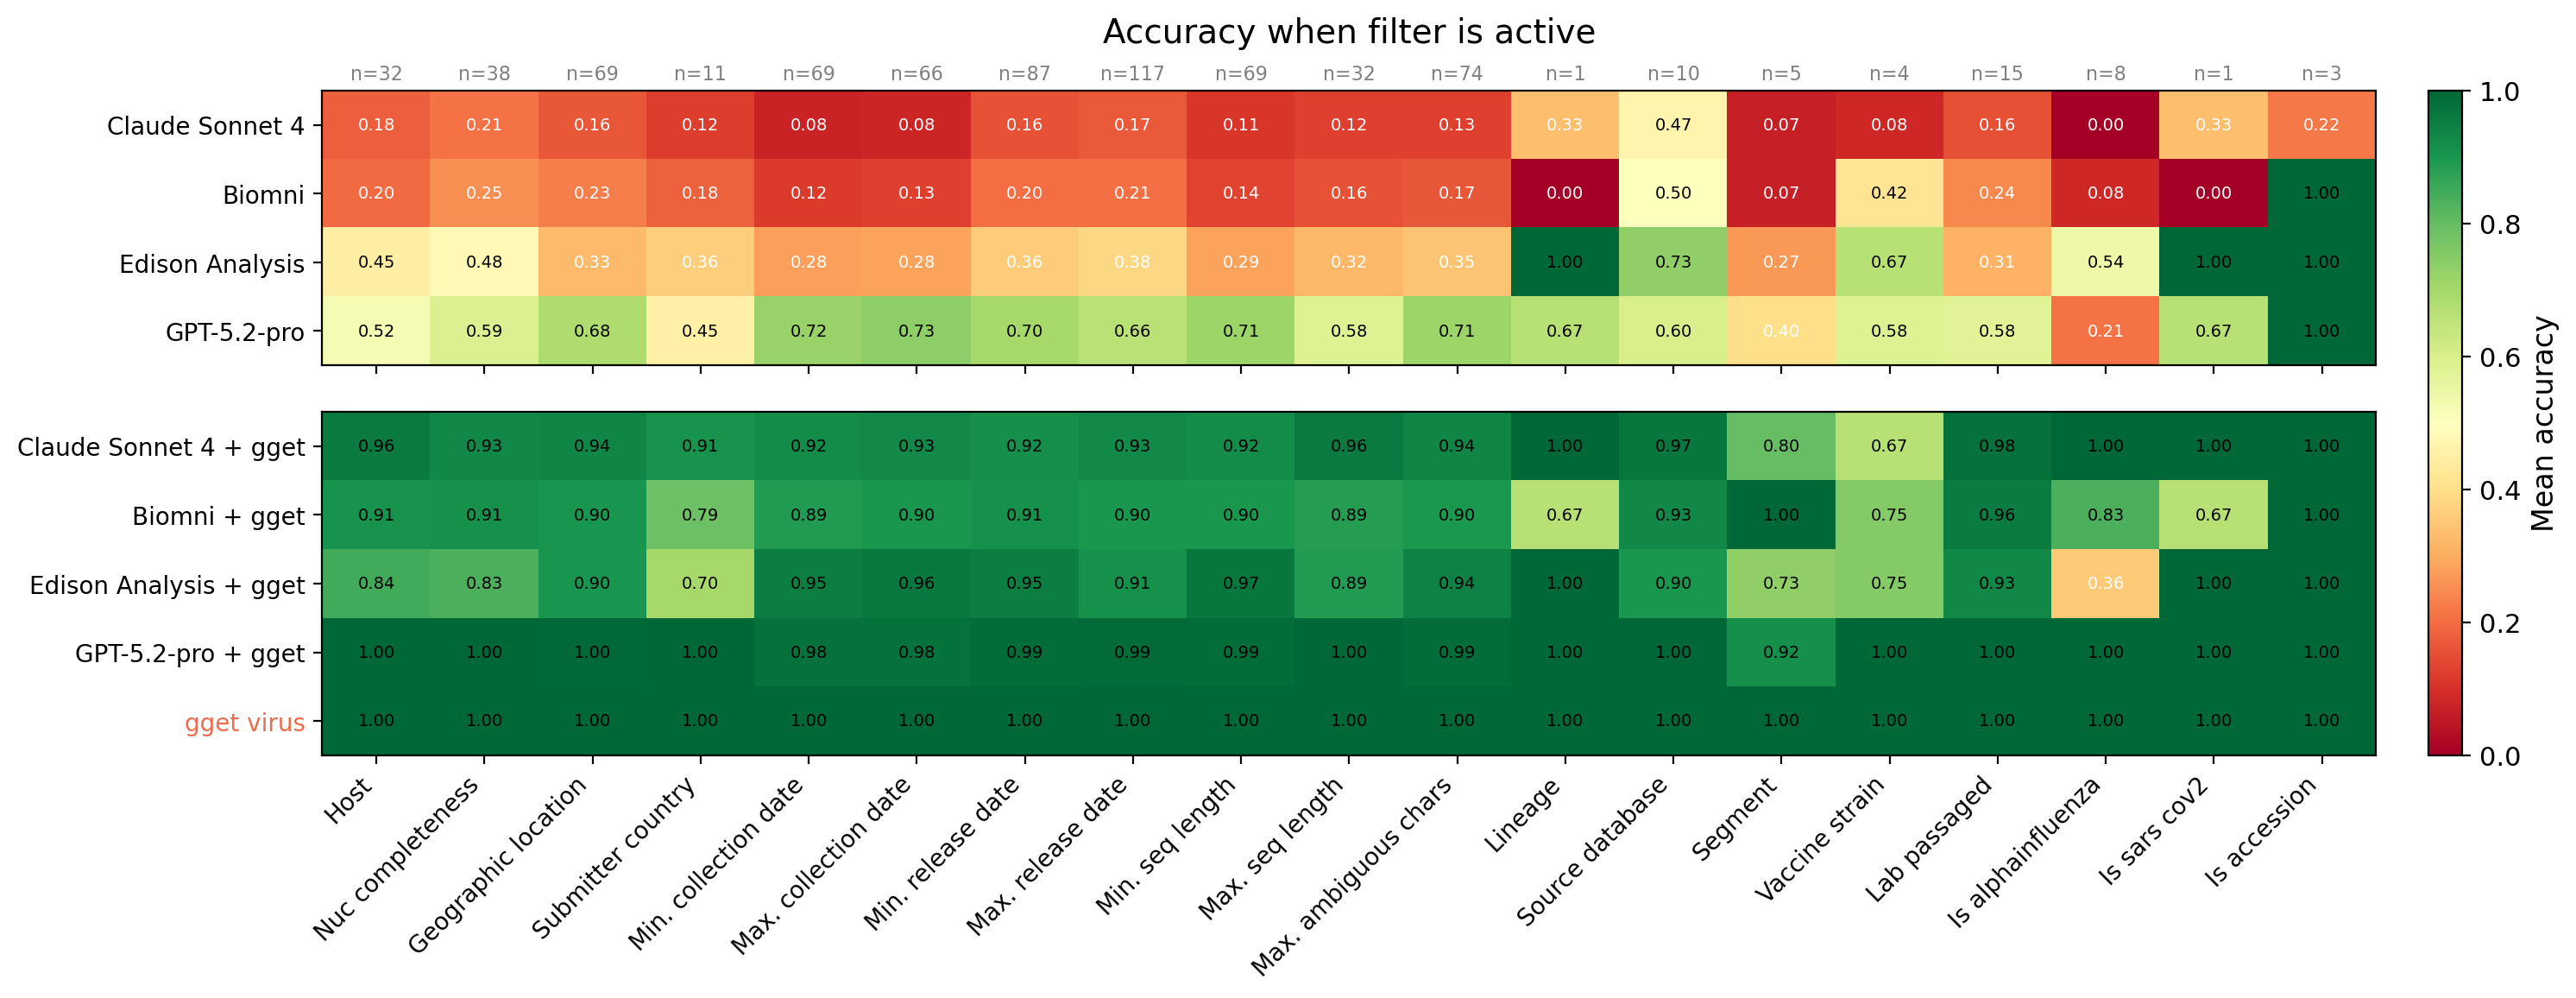

In [15]:
# Heatmap: accuracy when filter is PRESENT
n_filters = len(active_filters)

# Pretty filter labels
filter_labels = [
    col.replace("_", " ").replace("min ", "min. ").replace("max ", "max. ").capitalize()
    for col in active_filters
]

left_matrix = np.array([filter_acc_present[name] for name in left_tech])  # (n_left, n_filters)
right_matrix = np.array([filter_acc_present[name] for name in right_tech])  # (n_right, n_filters)

fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(2, 2, width_ratios=[30, 0.5], height_ratios=[n_left, n_right],
                       wspace=0.05, hspace=0.15)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
ax_cb = fig.add_subplot(gs[:, 1])

cmap = "RdYlGn"
vmin, vmax = 0, 1

im0 = ax0.imshow(left_matrix, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
im1 = ax1.imshow(right_matrix, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

for mat, ax in [(left_matrix, ax0), (right_matrix, ax1)]:
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            if np.isnan(val):
                continue
            text_color = "white" if val < 0.4 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=FONTSIZE - 5, color=text_color)

ax0.set_yticks(range(n_left))
ax0.set_yticklabels(left_tech, fontsize=FONTSIZE - 2)
ax1.set_yticks(range(n_right))
ax1.set_yticklabels(right_tech, fontsize=FONTSIZE - 2)
for label in ax1.get_yticklabels():
    if "gget virus" == label.get_text():
        label.set_color(COLORS["gget virus"])

ax0.set_xticks(range(n_filters))
ax0.set_xticklabels([])
ax0.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False, labeltop=False)

ax1.set_xticks(range(n_filters))
ax1.set_xticklabels(filter_labels, fontsize=FONTSIZE - 2, rotation=45, ha="right")

ax0.set_title("Accuracy when filter is active", fontsize=FONTSIZE + 2, pad=20)

# Show n= above columns
for j, nq in enumerate(n_queries_per_filter):
    ax0.text(j, -0.6, f"n={nq}", ha="center", va="bottom",
             fontsize=FONTSIZE - 4, color="gray")

cb = fig.colorbar(im1, cax=ax_cb, orientation="vertical")
ax_cb.yaxis.set_label_position('right')
ax_cb.tick_params(labelsize=FONTSIZE - 1, left=False, right=True, labelleft=False, labelright=True)
ax_cb.set_ylabel("Mean accuracy", fontsize=FONTSIZE)
for spine in ["top", "bottom", "left"]:
    ax_cb.spines[spine].set_visible(False)

fig.subplots_adjust(wspace=0.03, hspace=0.12)
fig.tight_layout(rect=[0, 0, 1, 1])

# fig.savefig("../figures/heatmap_filter_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

## Accuracy difference: filter present vs absent

Shows the accuracy drop (or gain) when a filter is active compared to when it is not.
Negative values (red) indicate the filter hurts accuracy.

/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_82368/2684960713.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])


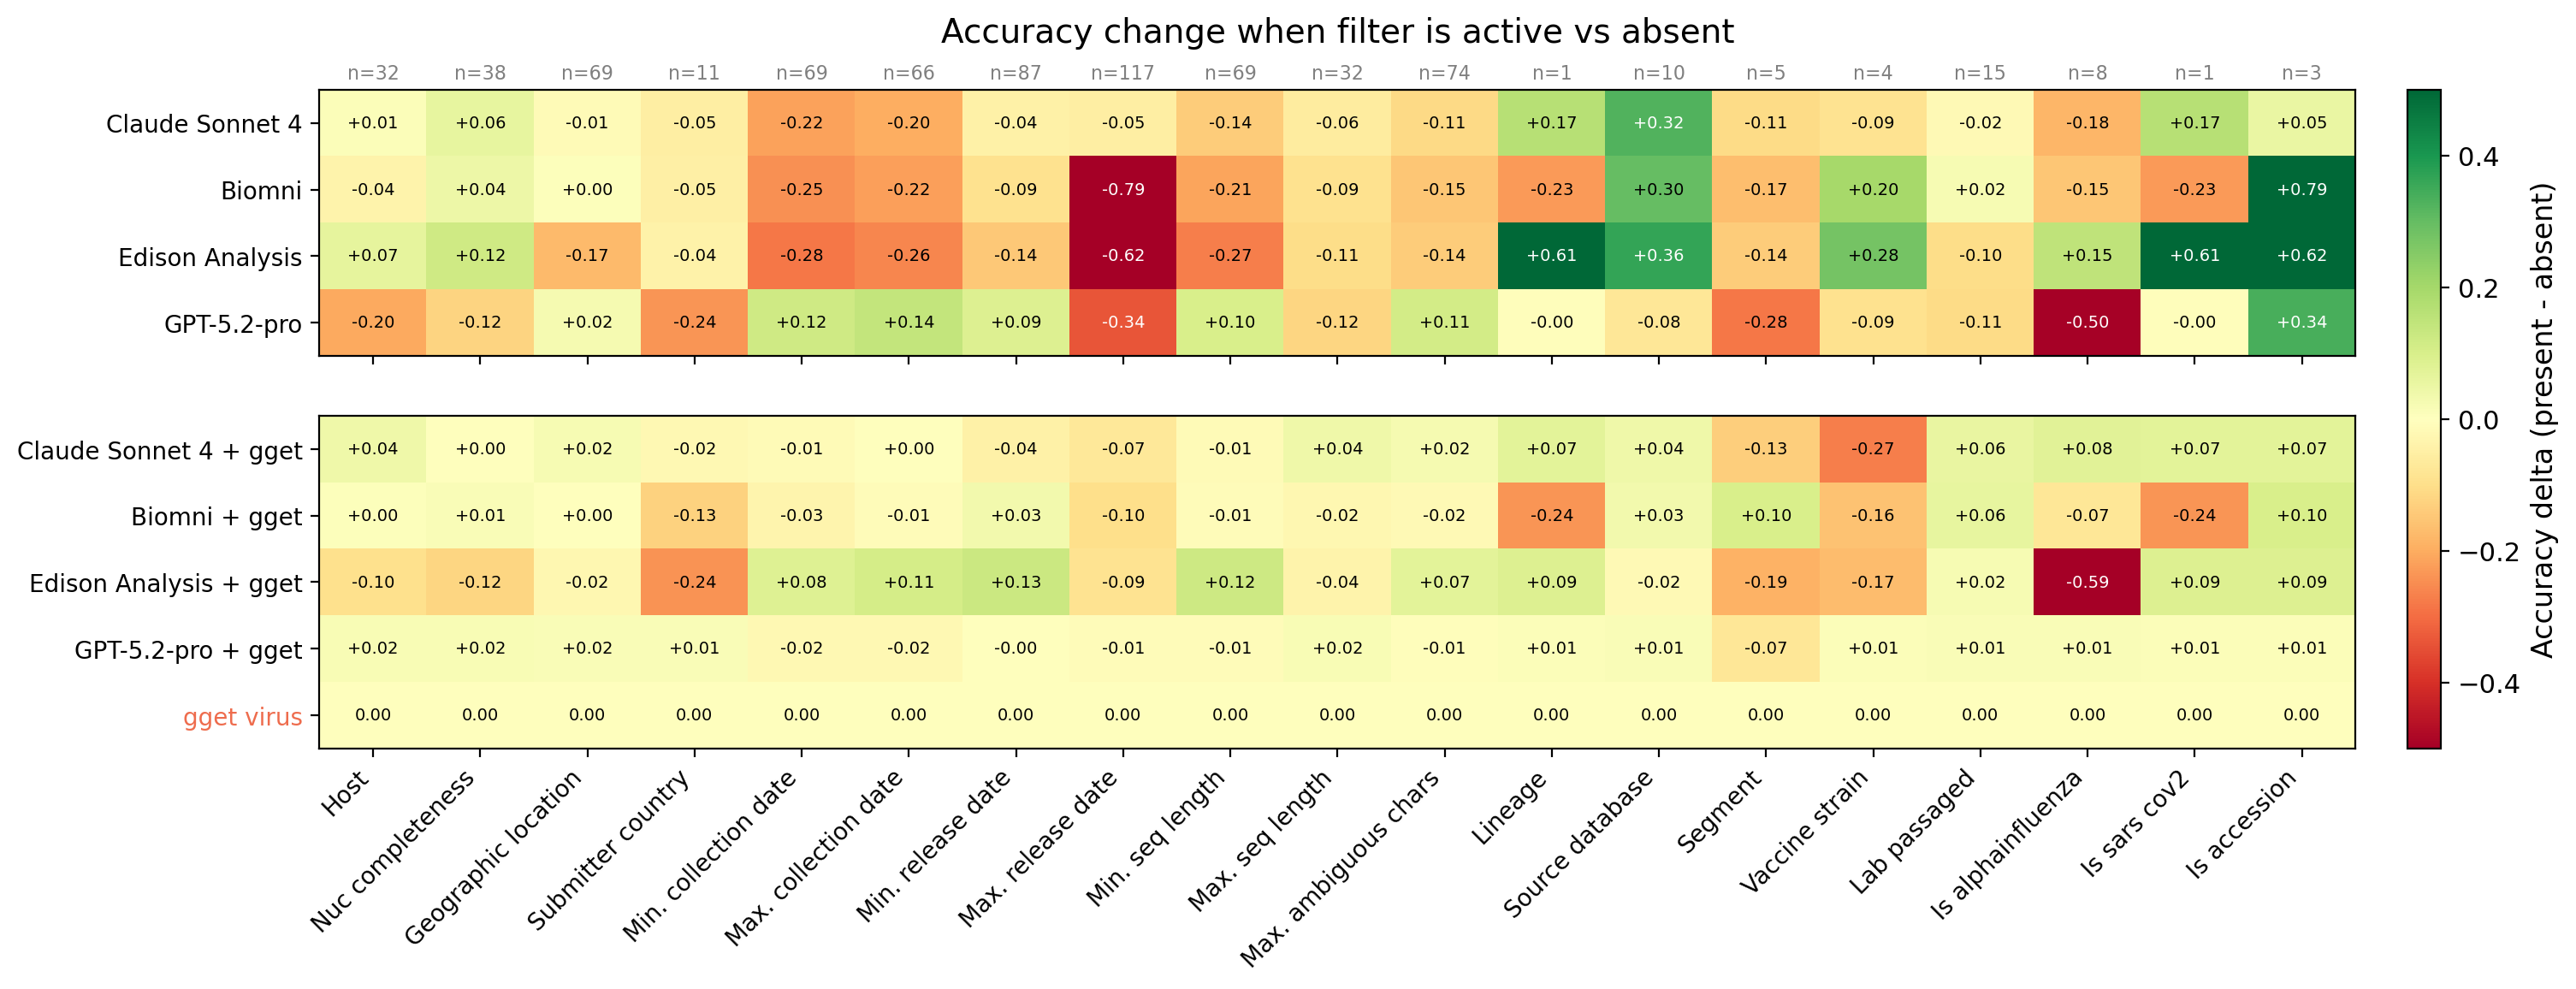

In [16]:
# Delta heatmap: accuracy(present) - accuracy(absent)
left_present = np.array([filter_acc_present[name] for name in left_tech])
left_absent = np.array([filter_acc_absent[name] for name in left_tech])
right_present = np.array([filter_acc_present[name] for name in right_tech])
right_absent = np.array([filter_acc_absent[name] for name in right_tech])

left_delta = left_present - left_absent
right_delta = right_present - right_absent

fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(2, 2, width_ratios=[30, 0.5], height_ratios=[n_left, n_right],
                       wspace=0.05, hspace=0.2)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
ax_cb = fig.add_subplot(gs[:, 1])

cmap = "RdYlGn"
vlim = 0.5

im0 = ax0.imshow(left_delta, aspect="auto", cmap=cmap, vmin=-vlim, vmax=vlim)
im1 = ax1.imshow(right_delta, aspect="auto", cmap=cmap, vmin=-vlim, vmax=vlim)

for mat, ax in [(left_delta, ax0), (right_delta, ax1)]:
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            if np.isnan(val):
                continue
            text_color = "white" if abs(val) > 0.3 else "black"
            sign = "+" if val > 0 else ""
            ax.text(j, i, f"{sign}{val:.2f}", ha="center", va="center",
                    fontsize=FONTSIZE - 5, color=text_color)

ax0.set_yticks(range(n_left))
ax0.set_yticklabels(left_tech, fontsize=FONTSIZE - 2)
ax1.set_yticks(range(n_right))
ax1.set_yticklabels(right_tech, fontsize=FONTSIZE - 2)
for label in ax1.get_yticklabels():
    if "gget virus" == label.get_text():
        label.set_color(COLORS["gget virus"])

ax0.set_xticks(range(n_filters))
ax0.set_xticklabels([])
ax0.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False, labeltop=False)

ax1.set_xticks(range(n_filters))
ax1.set_xticklabels(filter_labels, fontsize=FONTSIZE - 2, rotation=45, ha="right")

ax0.set_title("Accuracy change when filter is active vs absent", fontsize=FONTSIZE + 2, pad=20)

for j, nq in enumerate(n_queries_per_filter):
    ax0.text(j, -0.6, f"n={nq}", ha="center", va="bottom",
             fontsize=FONTSIZE - 4, color="gray")

cb = fig.colorbar(im1, cax=ax_cb, orientation="vertical")
ax_cb.yaxis.set_label_position('right')
ax_cb.tick_params(labelsize=FONTSIZE - 1, left=False, right=True, labelleft=False, labelright=True)
ax_cb.set_ylabel("Accuracy delta (present - absent)", fontsize=FONTSIZE)
for spine in ["top", "bottom", "left"]:
    ax_cb.spines[spine].set_visible(False)

fig.subplots_adjust(wspace=0.03, hspace=0.12)
fig.tight_layout(rect=[0, 0, 1, 1])

# fig.savefig("../figures/heatmap_filter_delta.png", dpi=300, bbox_inches="tight")
plt.show()

## Accuracy vs number of active filters

Do queries with more filters tend to be harder?

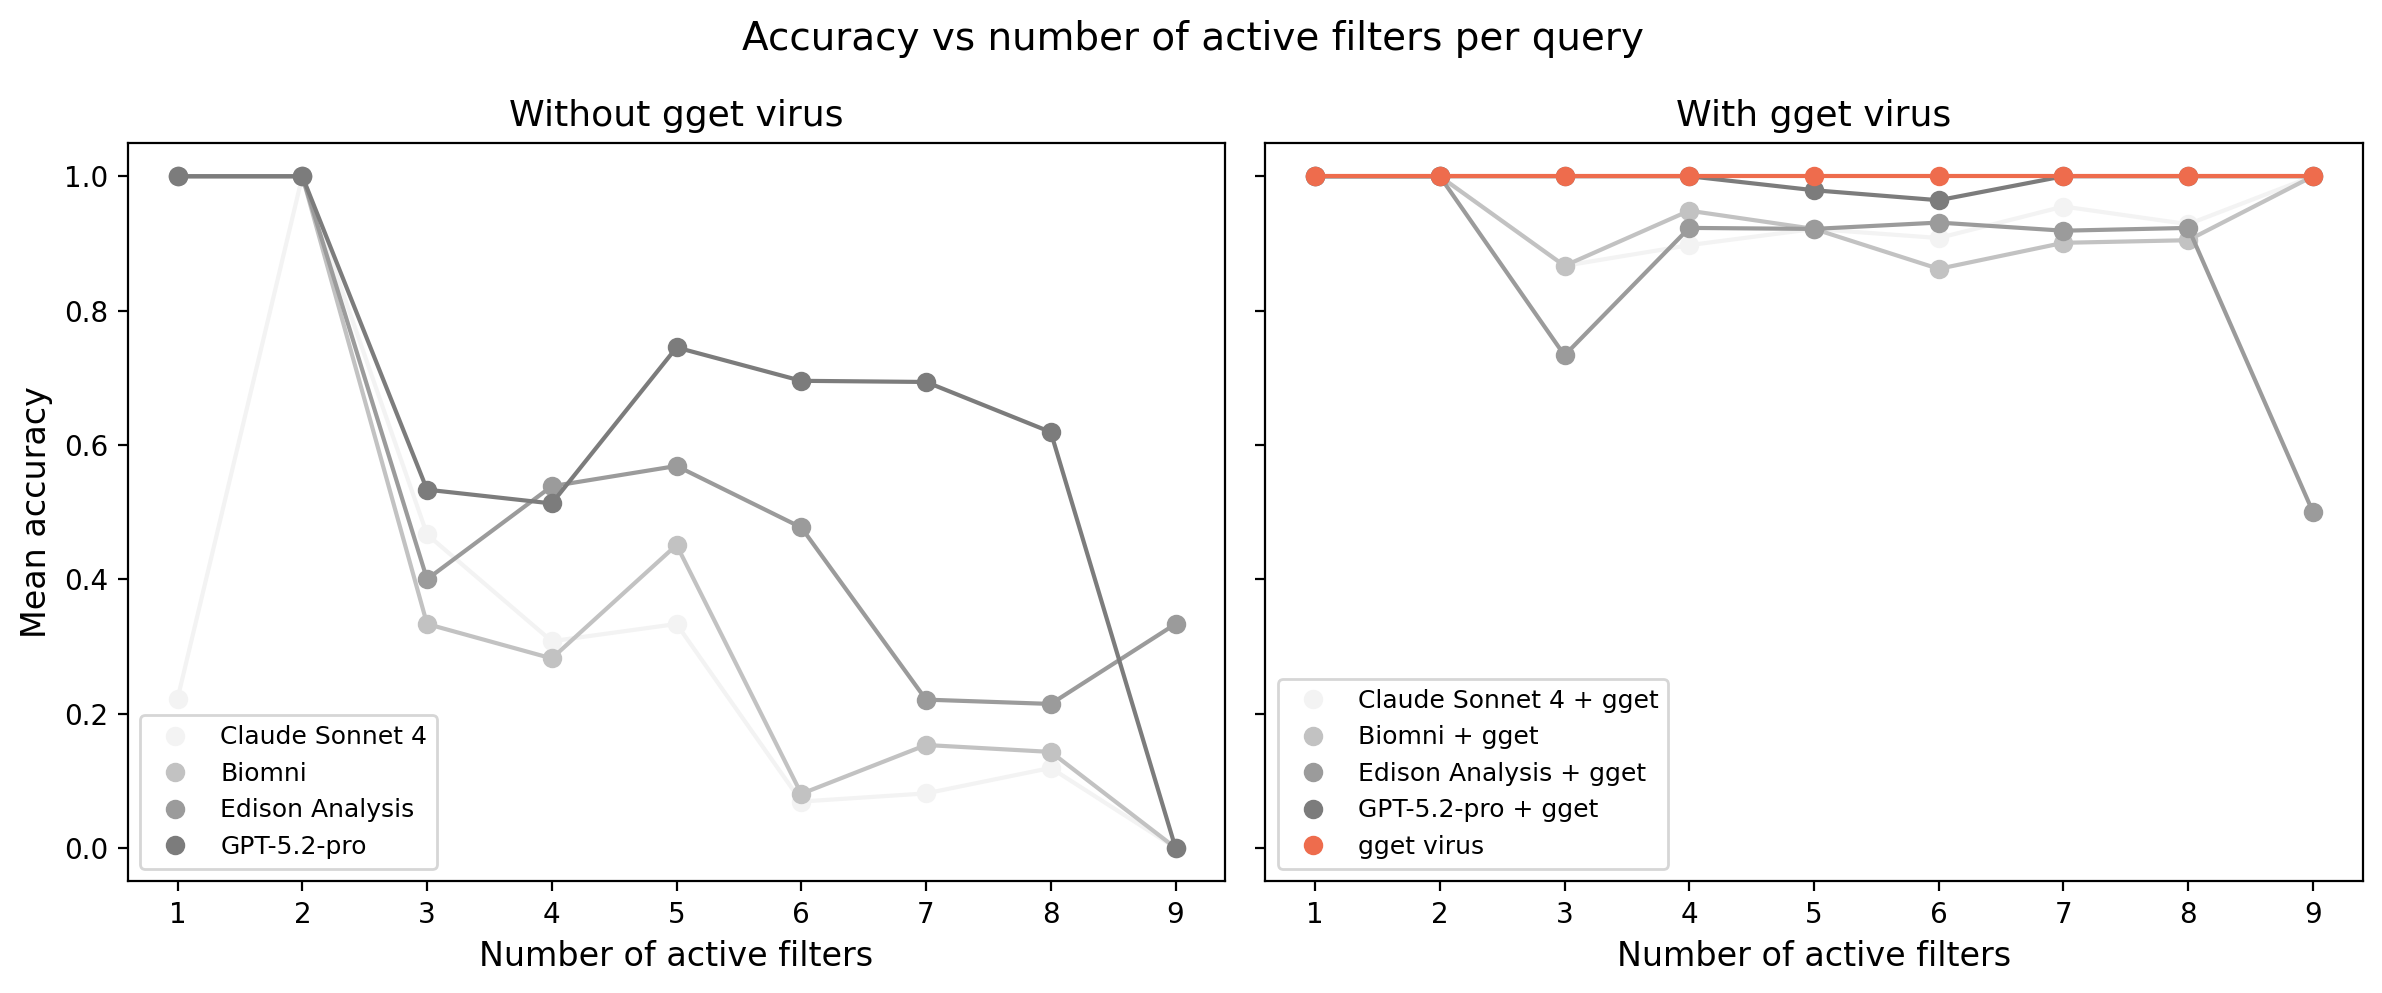

In [17]:
# Count number of active filters per query
configs["n_filters"] = configs[FILTER_COLS].notna().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, tech_list, title in [
    (axes[0], left_tech, "Without gget virus"),
    (axes[1], right_tech, "With gget virus"),
]:
    for name in tech_list:
        qid_acc = tech_accuracy.get(name, {})
        # Group by n_filters
        nf_acc = {}
        for _, row in configs.iterrows():
            qid = row["query_id"]
            nf = row["n_filters"]
            if qid in qid_acc:
                nf_acc.setdefault(nf, []).append(qid_acc[qid])

        nfs = sorted(nf_acc.keys())
        means = [np.nanmean(nf_acc[nf]) for nf in nfs]
        facecolor = COLORS[name]
        edgecolor = COLORS[name]
        ax.plot(nfs, means, '-', color=edgecolor, lw=1.5)
        ax.plot(nfs, means, 'o', markerfacecolor=facecolor, markeredgecolor=edgecolor,
                markersize=6, label=name)

    ax.set_xlabel("Number of active filters", fontsize=FONTSIZE)
    ax.set_title(title, fontsize=FONTSIZE + 1)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=FONTSIZE - 3, loc="lower left")

axes[0].set_ylabel("Mean accuracy", fontsize=FONTSIZE)
fig.suptitle("Accuracy vs number of active filters per query", fontsize=FONTSIZE + 2)
fig.tight_layout()
# fig.savefig("../figures/accuracy_vs_nfilters.png", dpi=300, bbox_inches="tight")
plt.show()

## Accuracy by specific filter values

For filters with distinct categorical values (e.g., geographic_location, host,
nuc_completeness), show accuracy per value.

/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_82368/2371854987.py:21: RuntimeWarning: Mean of empty slice
  val_acc[name].append(np.nanmean(accs) if accs else np.nan)
/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_82368/2371854987.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])


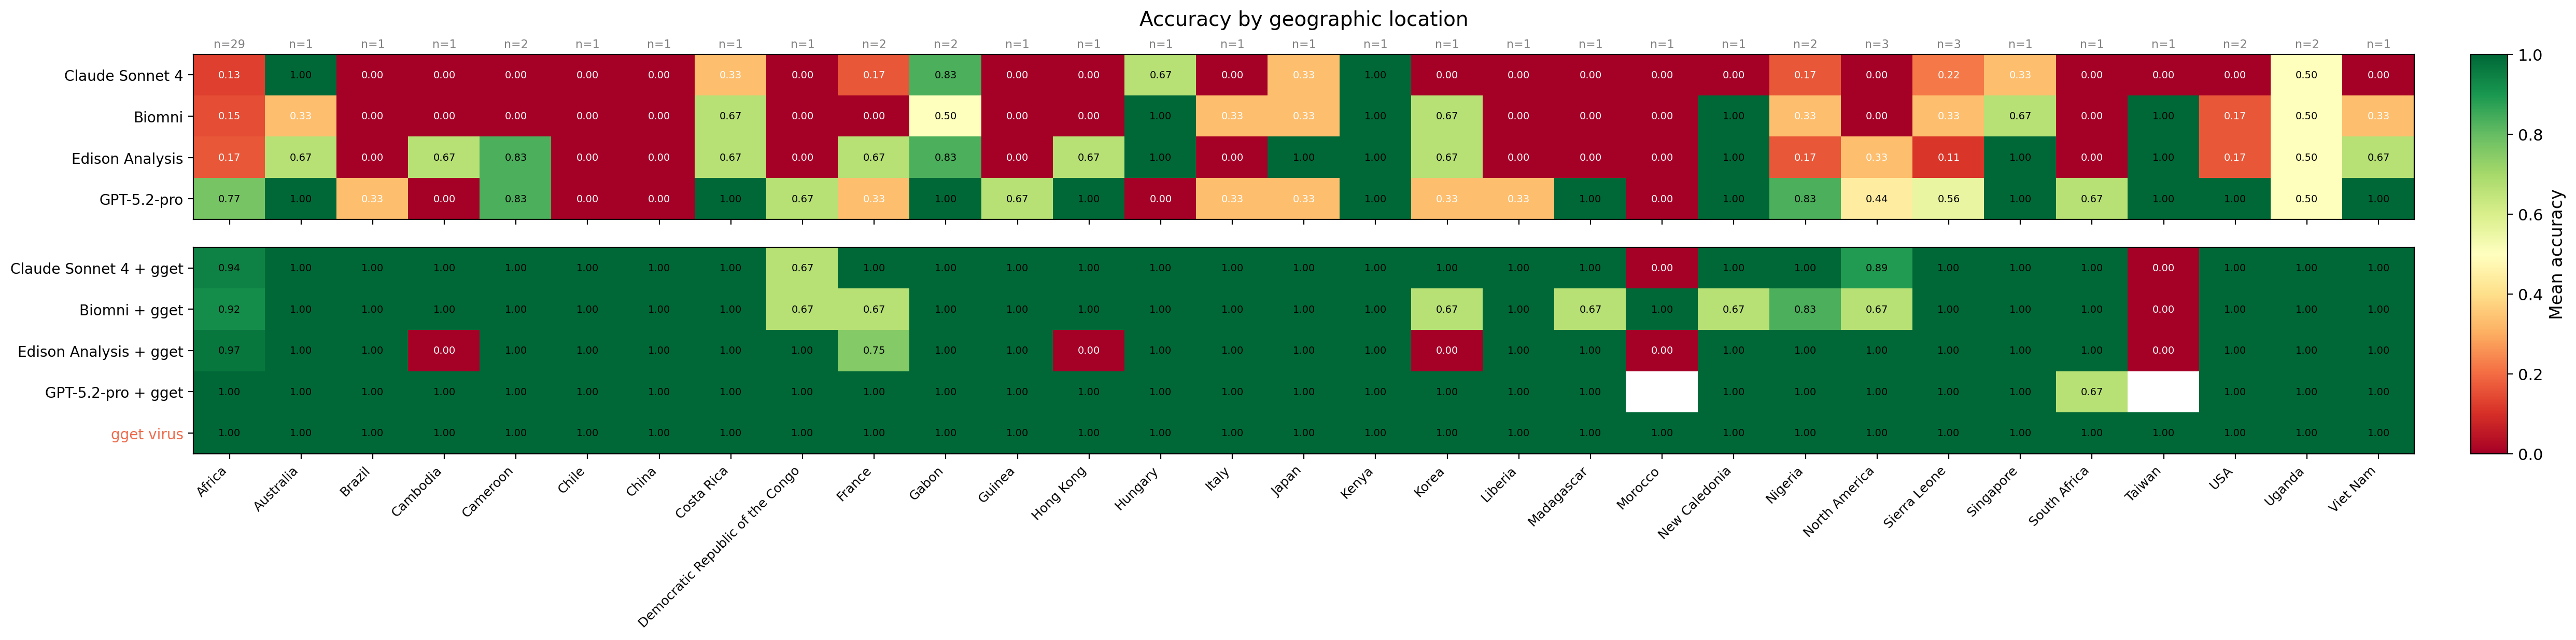

/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_82368/2371854987.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])


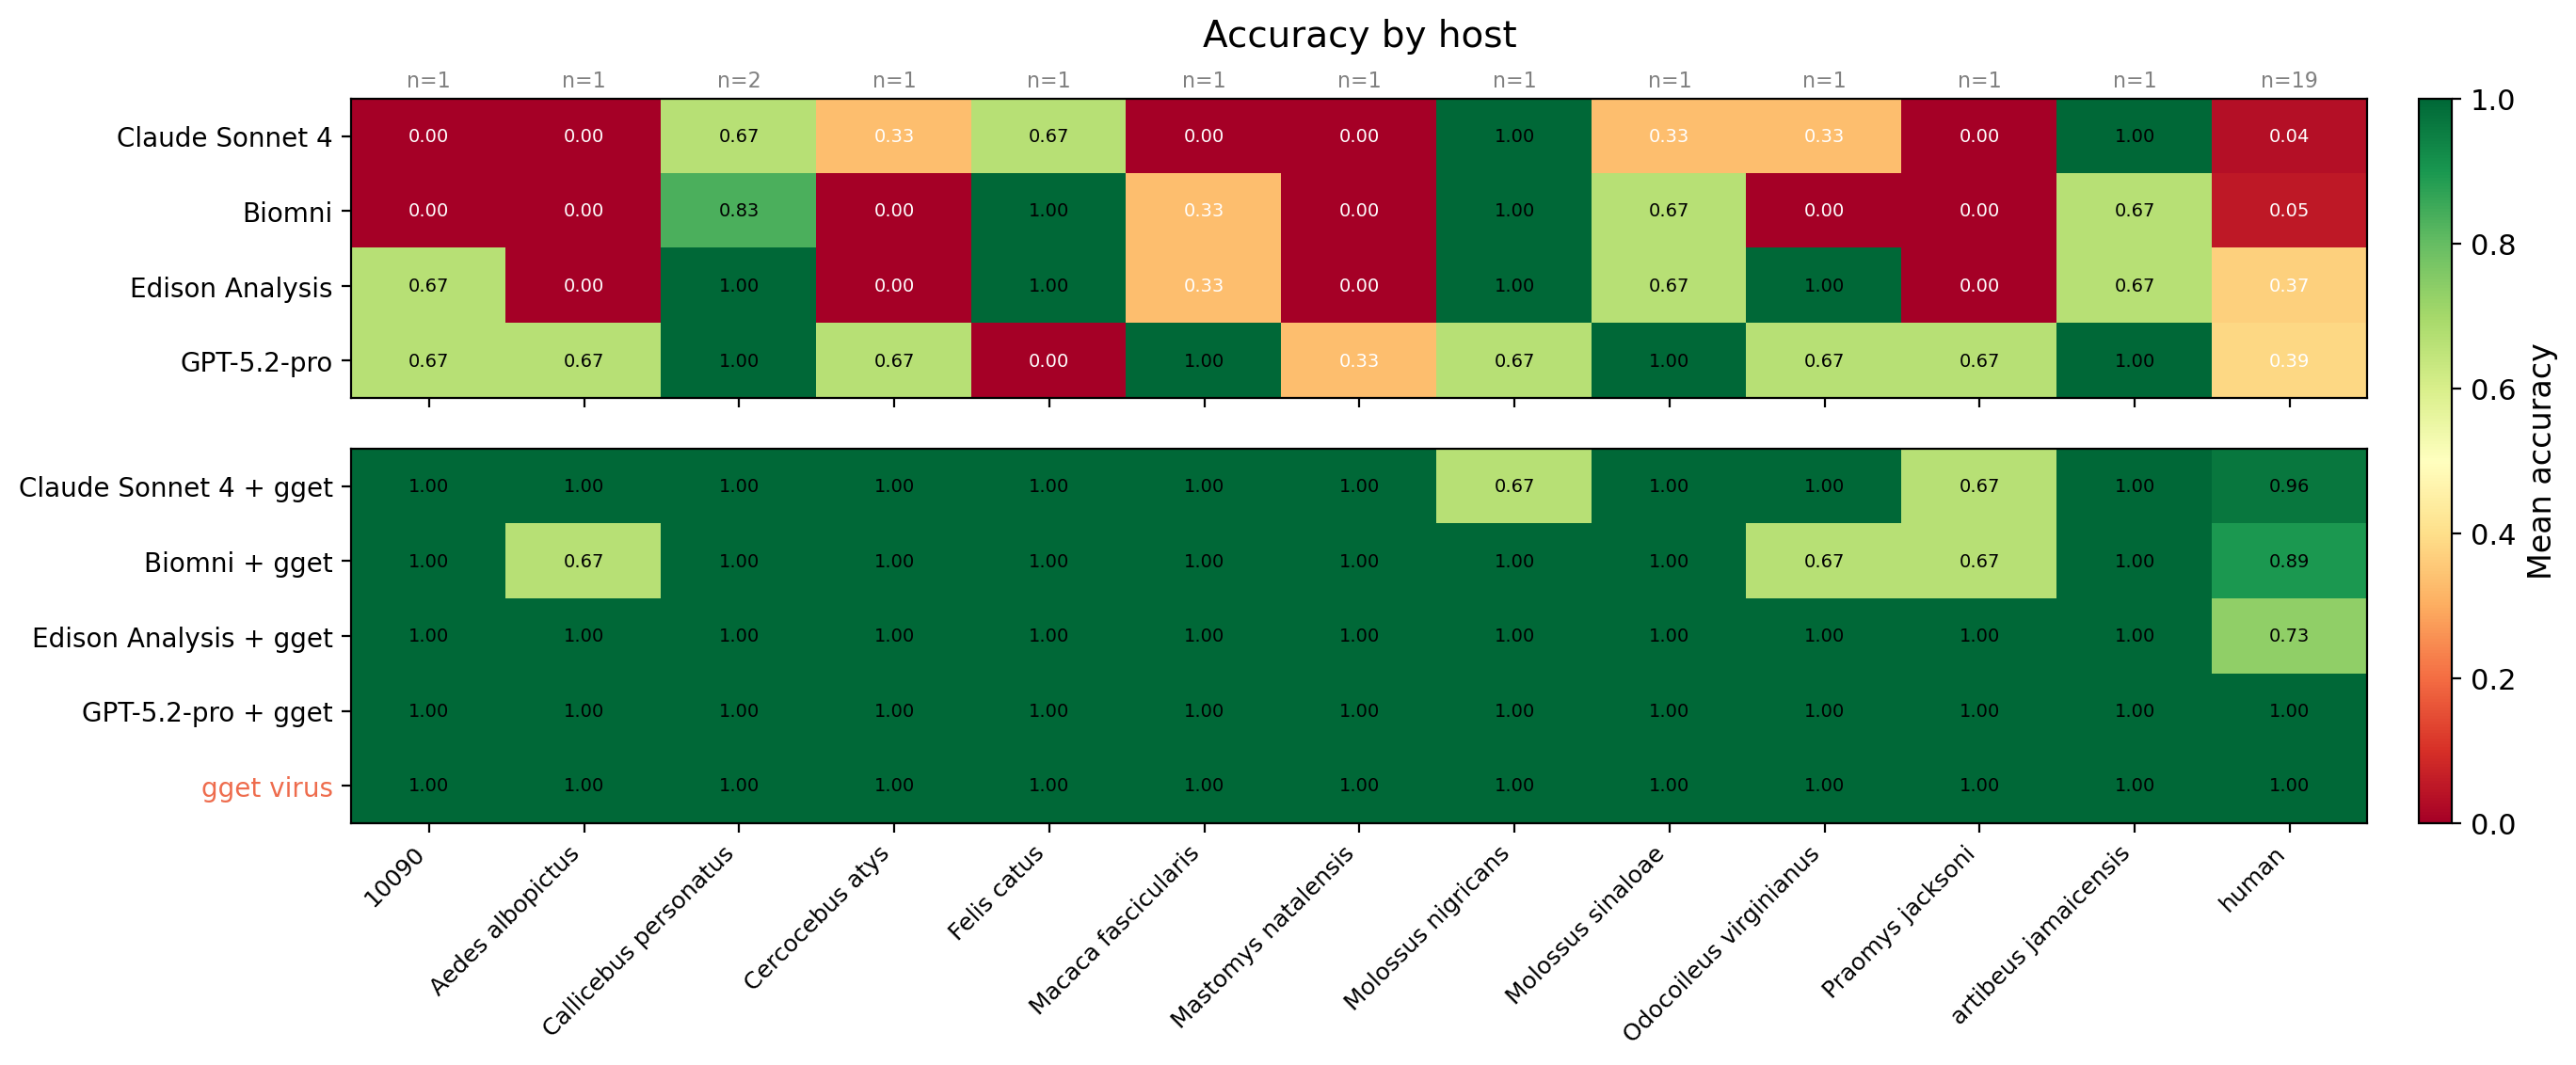

/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_82368/2371854987.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])


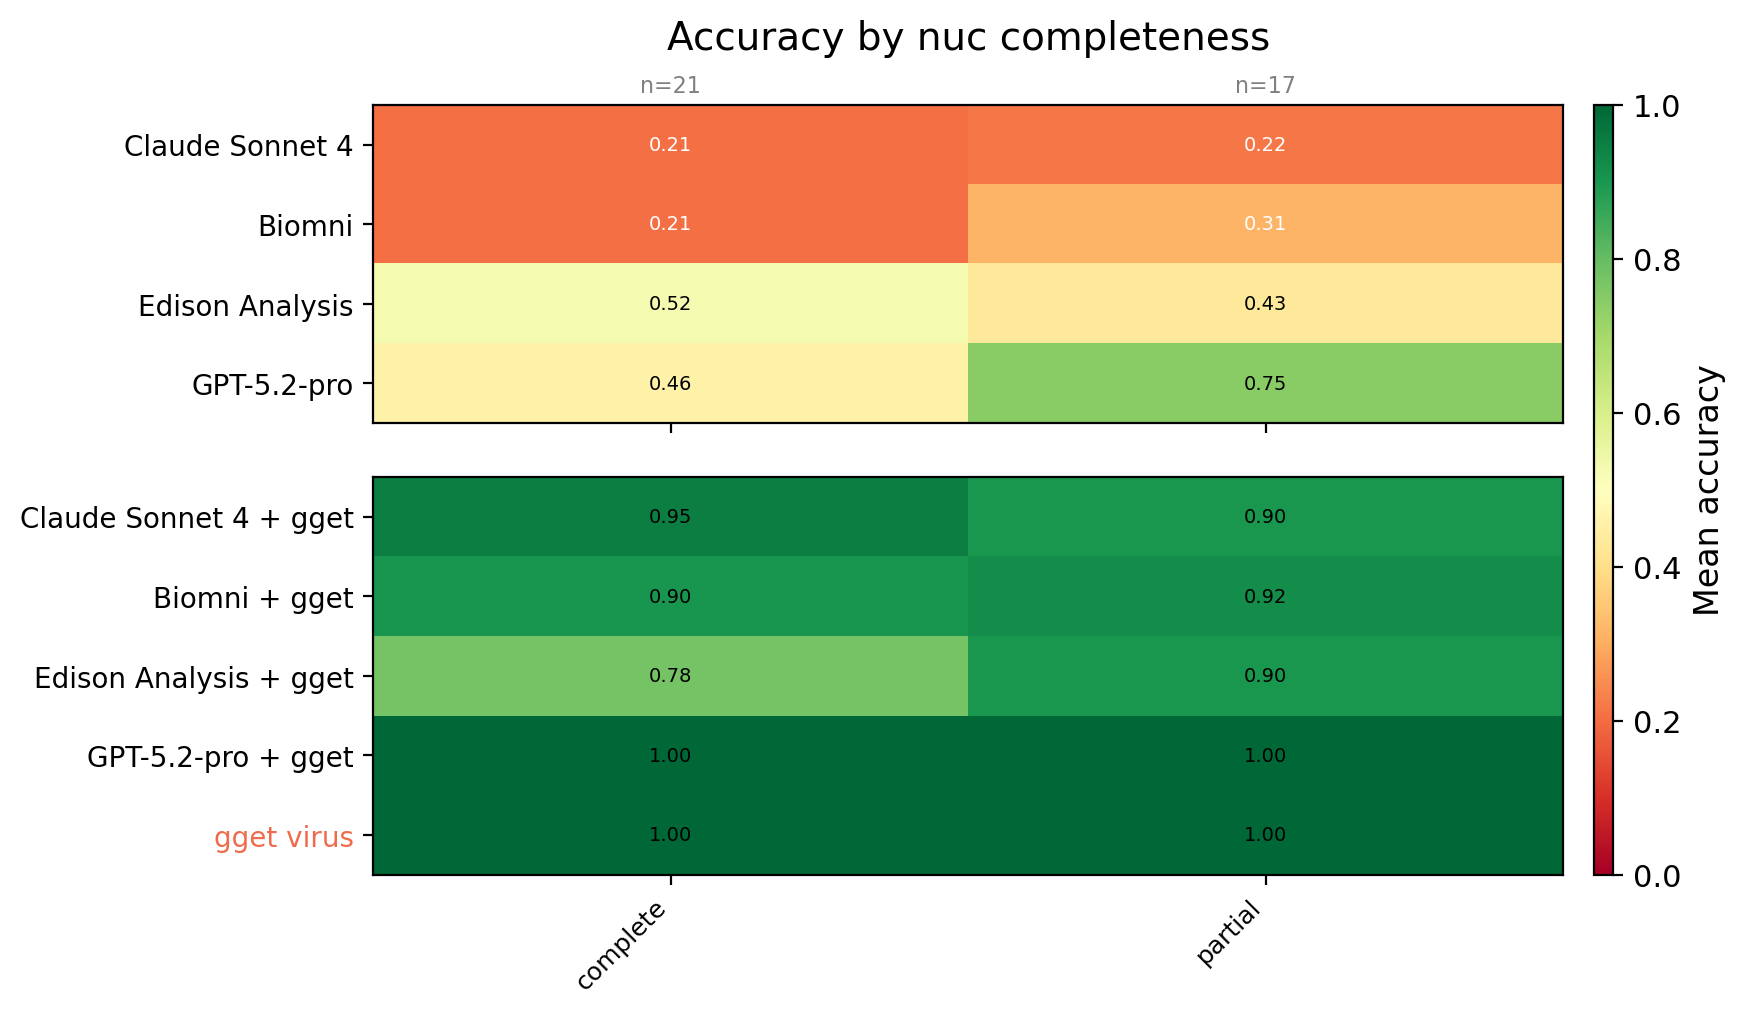

/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_82368/2371854987.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])


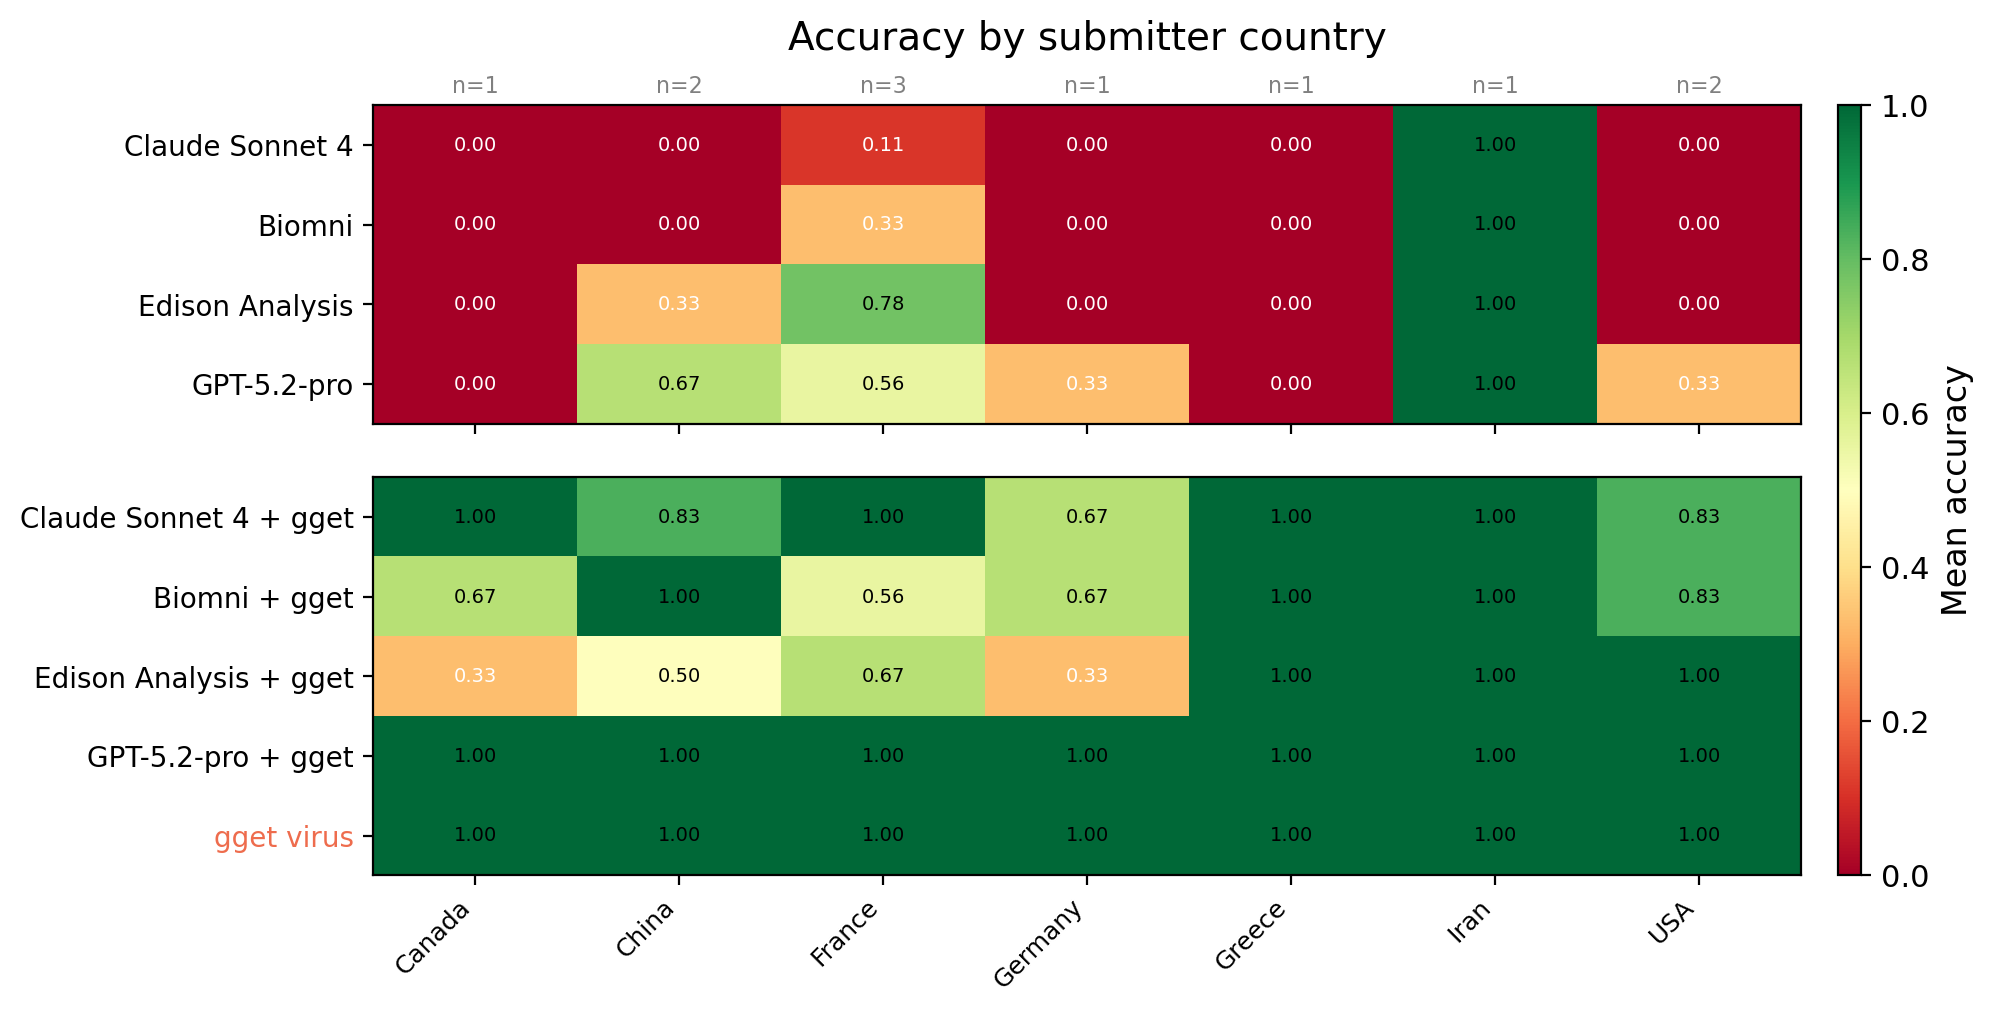

/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_82368/2371854987.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])


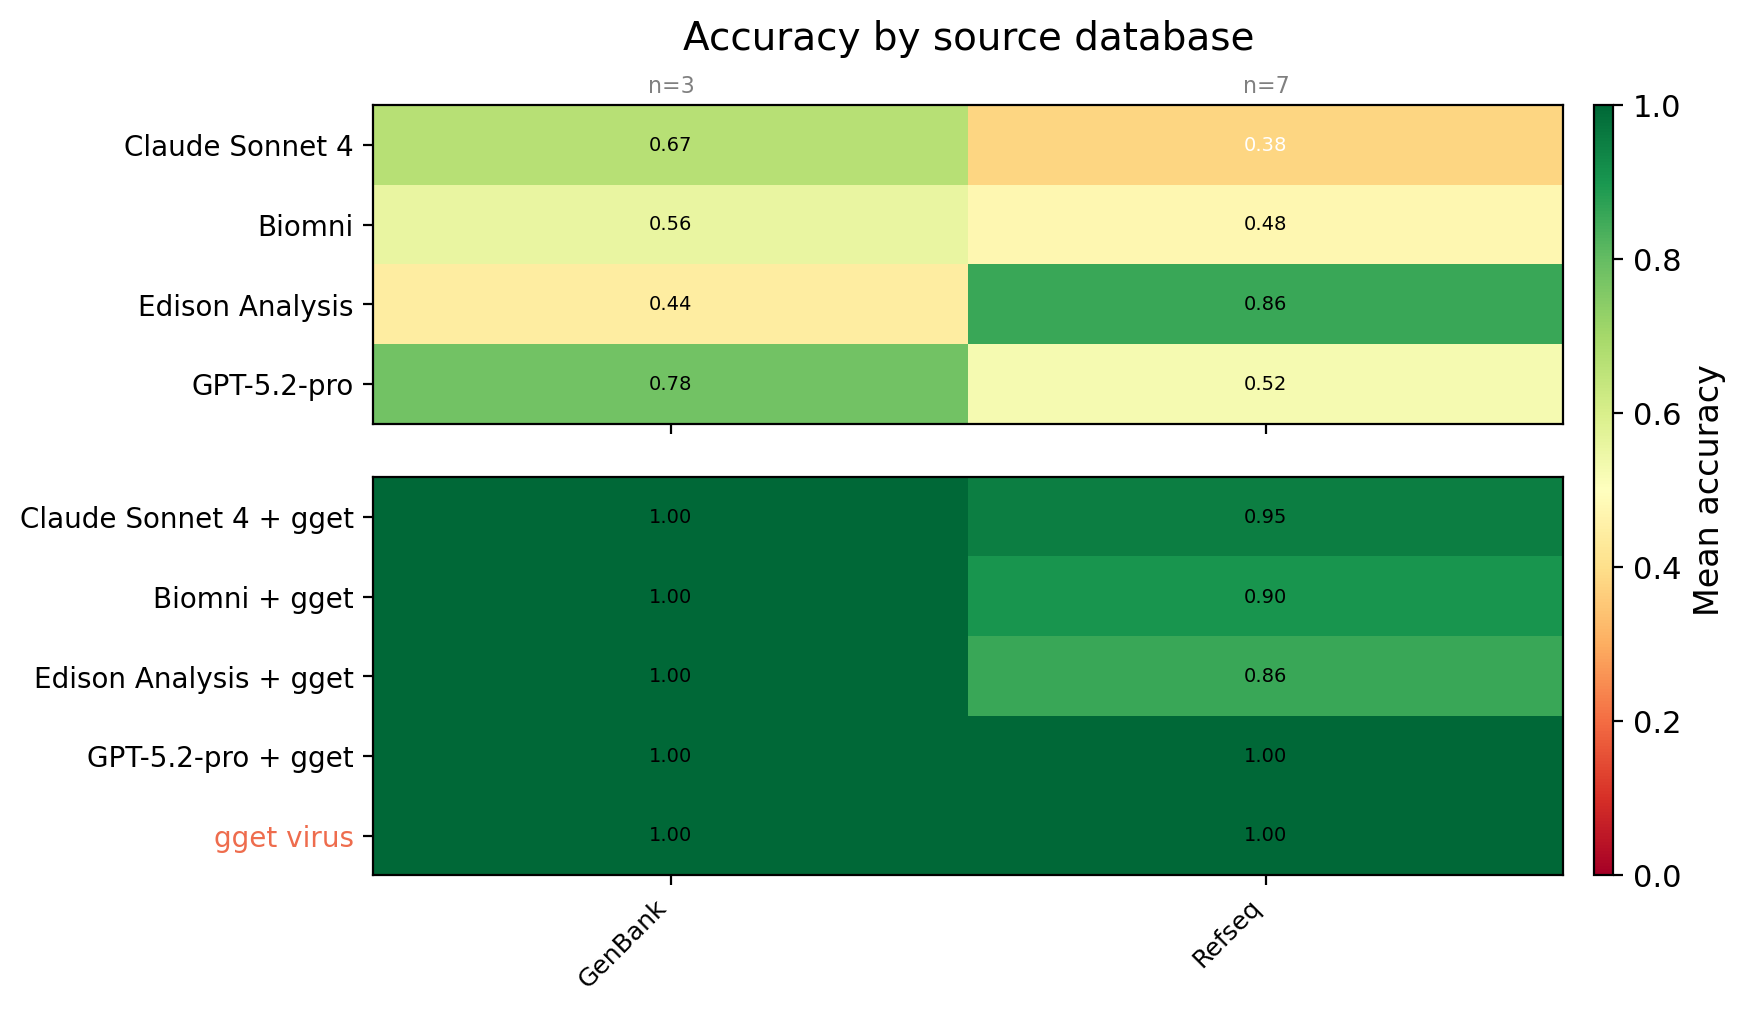

/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_82368/2371854987.py:21: RuntimeWarning: Mean of empty slice
  val_acc[name].append(np.nanmean(accs) if accs else np.nan)
/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_82368/2371854987.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])


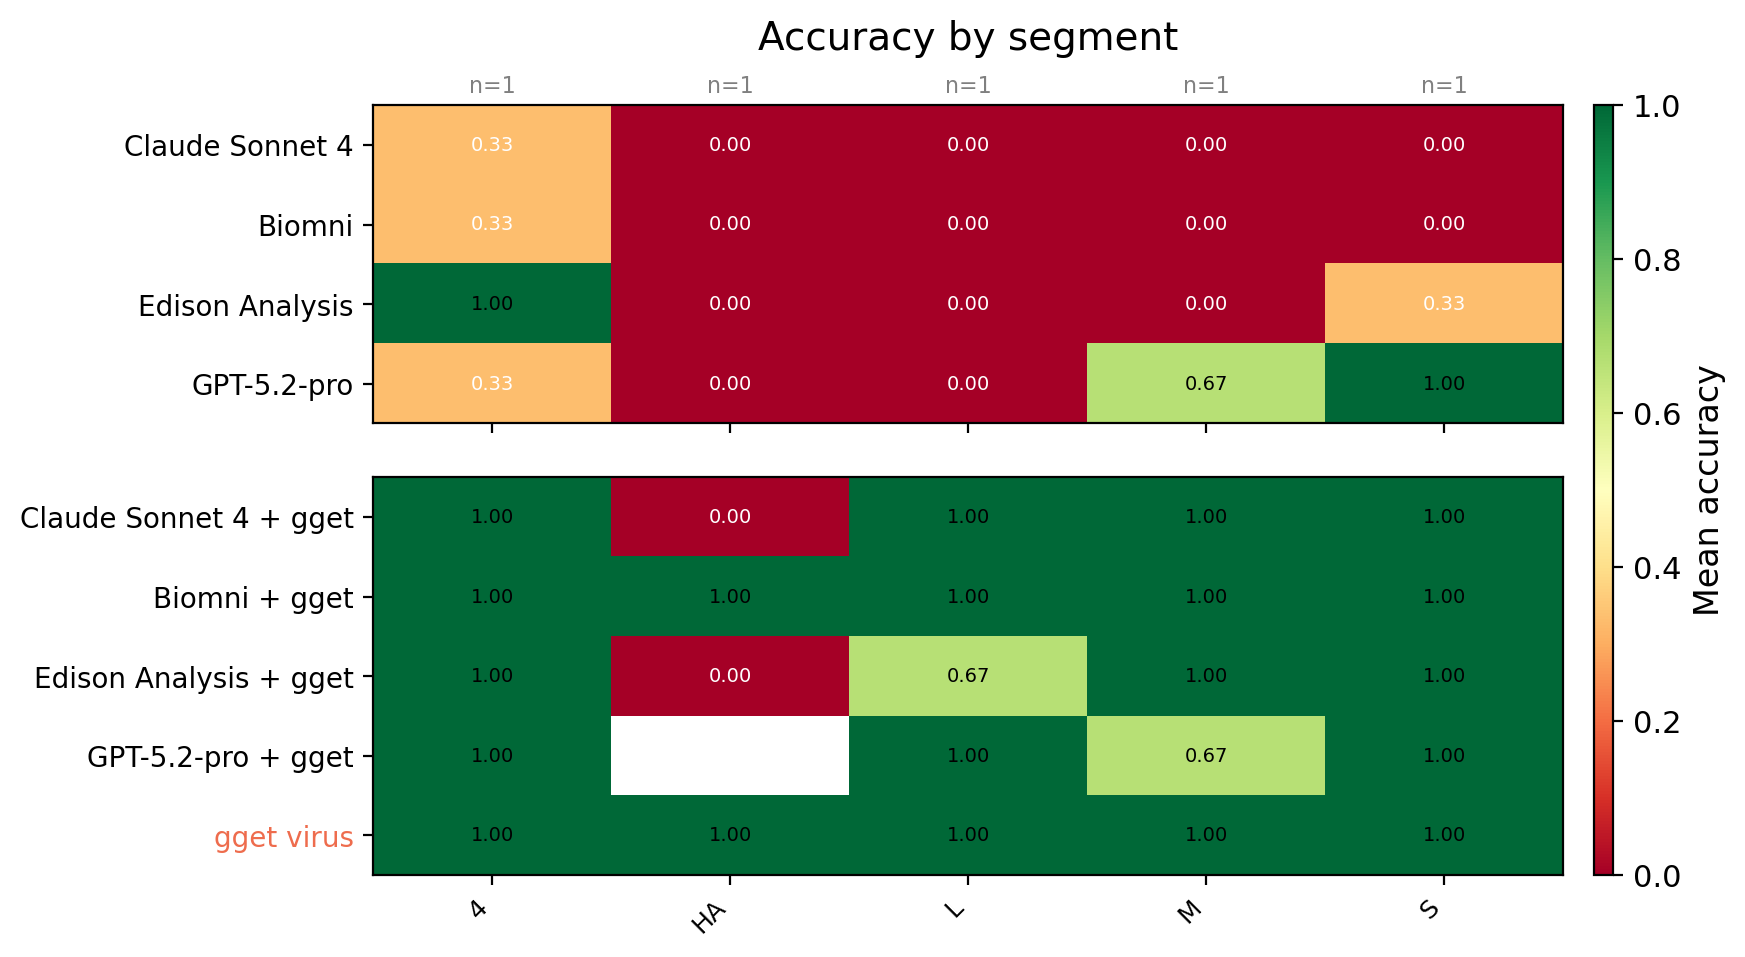

In [18]:
# Categorical filters with a manageable number of unique values
CATEGORICAL_FILTERS = [
    "geographic_location", "host", "nuc_completeness", "submitter_country",
    "source_database", "segment",
]

for col in CATEGORICAL_FILTERS:
    unique_vals = sorted(configs[col].dropna().unique())
    if len(unique_vals) < 2:
        continue

    # Mean accuracy per value, per technology
    val_acc = {name: [] for name in TECHNOLOGIES}
    n_per_val = []
    for val in unique_vals:
        qids = set(configs[configs[col] == val]["query_id"].tolist())
        n_per_val.append(len(qids))
        for name in TECHNOLOGIES:
            qid_acc = tech_accuracy.get(name, {})
            accs = [qid_acc[qid] for qid in qids if qid in qid_acc]
            val_acc[name].append(np.nanmean(accs) if accs else np.nan)

    left_matrix = np.array([val_acc[name] for name in left_tech])
    right_matrix = np.array([val_acc[name] for name in right_tech])

    fig = plt.figure(figsize=(max(8, len(unique_vals) * 0.8 + 4), 5))
    gs_inner = gridspec.GridSpec(2, 2, width_ratios=[30, 0.5],
                                height_ratios=[n_left, n_right], wspace=0.05, hspace=0.15)
    ax0 = fig.add_subplot(gs_inner[0, 0])
    ax1 = fig.add_subplot(gs_inner[1, 0], sharex=ax0)
    ax_cb = fig.add_subplot(gs_inner[:, 1])

    im0 = ax0.imshow(left_matrix, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
    im1 = ax1.imshow(right_matrix, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

    for mat, ax in [(left_matrix, ax0), (right_matrix, ax1)]:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val_num = mat[i, j]
                if np.isnan(val_num):
                    continue
                text_color = "white" if val_num < 0.4 else "black"
                ax.text(j, i, f"{val_num:.2f}", ha="center", va="center",
                        fontsize=FONTSIZE - 5, color=text_color)

    ax0.set_yticks(range(n_left))
    ax0.set_yticklabels(left_tech, fontsize=FONTSIZE - 2)
    ax1.set_yticks(range(n_right))
    ax1.set_yticklabels(right_tech, fontsize=FONTSIZE - 2)
    for label in ax1.get_yticklabels():
        if "gget virus" == label.get_text():
            label.set_color(COLORS["gget virus"])

    ax0.set_xticks(range(len(unique_vals)))
    ax0.set_xticklabels([])
    ax0.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False, labeltop=False)
    ax1.set_xticks(range(len(unique_vals)))
    ax1.set_xticklabels(unique_vals, fontsize=FONTSIZE - 3, rotation=45, ha="right")

    ax0.set_title(f"Accuracy by {col.replace('_', ' ')}", fontsize=FONTSIZE + 2, pad=20)

    for j, nq in enumerate(n_per_val):
        ax0.text(j, -0.6, f"n={nq}", ha="center", va="bottom",
                 fontsize=FONTSIZE - 4, color="gray")

    cb = fig.colorbar(im1, cax=ax_cb, orientation="vertical")
    ax_cb.yaxis.set_label_position('right')
    ax_cb.tick_params(labelsize=FONTSIZE - 1, left=False, right=True, labelleft=False, labelright=True)
    ax_cb.set_ylabel("Mean accuracy", fontsize=FONTSIZE)
    for spine in ["top", "bottom", "left"]:
        ax_cb.spines[spine].set_visible(False)

    fig.subplots_adjust(wspace=0.03, hspace=0.12)
    fig.tight_layout(rect=[0, 0, 1, 1])
    plt.show()

In [19]:
# # === Combined supplementary figure (A4 page) ===

# CATEGORICAL_FILTERS = [
#     "geographic_location", "host", "nuc_completeness", "submitter_country",
#     "source_database", "segment",
# ]

# def cap_first(s):
#     """Capitalize first letter, keep rest unchanged."""
#     return s[0].upper() + s[1:] if s else s

# # Precompute categorical filter data
# cat_data = {}
# for col in CATEGORICAL_FILTERS:
#     unique_vals = sorted(configs[col].dropna().unique(), key=lambda x: cap_first(str(x)))
#     if len(unique_vals) < 2:
#         continue
#     display_labels = [cap_first(str(v)) for v in unique_vals]
#     val_acc = {name: [] for name in TECHNOLOGIES}
#     n_per_val = []
#     for val in unique_vals:
#         qids = set(configs[configs[col] == val]["query_id"].tolist())
#         n_per_val.append(len(qids))
#         for name in TECHNOLOGIES:
#             qid_acc = tech_accuracy.get(name, {})
#             accs = [qid_acc[qid] for qid in qids if qid in qid_acc]
#             val_acc[name].append(np.nanmean(accs) if accs else np.nan)
#     display_labels = ["DRC" if v == "Democratic Republic of the Congo" else v for v in display_labels]
#     cat_data[col] = {
#         "vals": display_labels,
#         "val_acc": val_acc,
#         "n_per_val": n_per_val,
#     }

# HEATMAP_NUM_FS = 4  # fontsize for numbers inside heatmaps

# # ── Helper: draw split heatmap on pre-created axes pair ──
# def draw_split_heatmap(ax_top, ax_bot, matrix_left, matrix_right, col_labels,
#                        title, n_per_col, show_yticklabels=True,
#                        show_xticklabels=True, vmin=0, vmax=1, cmap="RdYlGn",
#                        fmt=".2f", text_thresh=0.4):
#     im0 = ax_top.imshow(matrix_left, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
#     im1 = ax_bot.imshow(matrix_right, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

#     for mat, ax in [(matrix_left, ax_top), (matrix_right, ax_bot)]:
#         for i in range(mat.shape[0]):
#             for j in range(mat.shape[1]):
#                 val = mat[i, j]
#                 if np.isnan(val):
#                     continue
#                 tc = "white" if val < text_thresh else "black"
#                 ax.text(j, i, f"{val:{fmt}}", ha="center", va="center",
#                         fontsize=HEATMAP_NUM_FS, color=tc)

#     ax_top.set_yticks(range(n_left))
#     ax_bot.set_yticks(range(n_right))
#     if show_yticklabels:
#         ax_top.set_yticklabels(left_tech, fontsize=6)
#         ax_bot.set_yticklabels(right_tech, fontsize=6)
#         for label in ax_bot.get_yticklabels():
#             if "gget virus" == label.get_text():
#                 label.set_color(COLORS["gget virus"])
#     else:
#         ax_top.set_yticklabels([])
#         ax_bot.set_yticklabels([])

#     ax_top.set_xticks(range(len(col_labels)))
#     ax_top.set_xticklabels([])
#     ax_top.tick_params(axis='x', bottom=True, top=False, labelbottom=False)
#     ax_bot.set_xticks(range(len(col_labels)))
#     if show_xticklabels:
#         ax_bot.set_xticklabels(col_labels, fontsize=5, rotation=45, ha="right")
#     else:
#         ax_bot.set_xticklabels([])

#     ax_top.set_title(title, fontsize=8, pad=12)

#     if n_per_col is not None:
#         for j, nq in enumerate(n_per_col):
#             ax_top.text(j, -0.6, f"n={nq}", ha="center", va="bottom",
#                         fontsize=4, color="gray")

#     return im1

# # ── Helper: draw stacked A+B heatmaps with shared x-axis ──
# def draw_stacked_heatmaps_shared_x(subfig, mat_a_left, mat_a_right, mat_b_left, mat_b_right,
#                                     col_labels, n_per_col):
#     gs = subfig.add_gridspec(
#         5, 2,
#         width_ratios=[30, 0.5],
#         height_ratios=[n_left, n_right, 0.3, n_left, n_right],
#         wspace=0.08, hspace=0.08,
#     )

#     ax_a0 = subfig.add_subplot(gs[0, 0])
#     ax_a1 = subfig.add_subplot(gs[1, 0], sharex=ax_a0)
#     ax_cb_a = subfig.add_subplot(gs[0:2, 1])

#     im_a0 = ax_a0.imshow(mat_a_left, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
#     im_a1 = ax_a1.imshow(mat_a_right, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

#     ax_b0 = subfig.add_subplot(gs[3, 0], sharex=ax_a0)
#     ax_b1 = subfig.add_subplot(gs[4, 0], sharex=ax_a0)
#     ax_cb_b = subfig.add_subplot(gs[3:5, 1])

#     im_b0 = ax_b0.imshow(mat_b_left, aspect="auto", cmap="RdYlGn", vmin=-0.5, vmax=0.5)
#     im_b1 = ax_b1.imshow(mat_b_right, aspect="auto", cmap="RdYlGn", vmin=-0.5, vmax=0.5)

#     for mat, ax in [(mat_a_left, ax_a0), (mat_a_right, ax_a1)]:
#         for i in range(mat.shape[0]):
#             for j in range(mat.shape[1]):
#                 val = mat[i, j]
#                 if np.isnan(val):
#                     continue
#                 tc = "white" if val < 0.4 else "black"
#                 ax.text(j, i, f"{val:.2f}", ha="center", va="center",
#                         fontsize=HEATMAP_NUM_FS, color=tc)

#     for mat, ax in [(mat_b_left, ax_b0), (mat_b_right, ax_b1)]:
#         for i in range(mat.shape[0]):
#             for j in range(mat.shape[1]):
#                 val = mat[i, j]
#                 if np.isnan(val):
#                     continue
#                 tc = "white" if abs(val) > 0.3 else "black"
#                 sign = "+" if val > 0 else ""
#                 ax.text(j, i, f"{sign}{val:.2f}", ha="center", va="center",
#                         fontsize=HEATMAP_NUM_FS, color=tc)

#     for ax, labels in [(ax_a0, left_tech), (ax_a1, right_tech),
#                         (ax_b0, left_tech), (ax_b1, right_tech)]:
#         ax.set_yticks(range(len(labels)))
#         ax.set_yticklabels(labels, fontsize=6)

#     for ax in [ax_a1, ax_b1]:
#         for label in ax.get_yticklabels():
#             if "gget virus" == label.get_text():
#                 label.set_color(COLORS["gget virus"])

#     for ax in [ax_a0, ax_a1, ax_b0]:
#         ax.set_xticks(range(len(col_labels)))
#         ax.set_xticklabels([])
#         ax.tick_params(axis='x', bottom=True, top=False, labelbottom=False)

#     ax_b1.set_xticks(range(len(col_labels)))
#     ax_b1.set_xticklabels(col_labels, fontsize=5, rotation=45, ha="right")

#     for j, nq in enumerate(n_per_col):
#         ax_a0.text(j, -0.6, f"n={nq}", ha="center", va="bottom", fontsize=4, color="gray")

#     cb_a = subfig.colorbar(im_a1, cax=ax_cb_a, orientation="vertical")
#     ax_cb_a.yaxis.set_label_position('right')
#     ax_cb_a.tick_params(labelsize=5, left=False, right=True, labelleft=False, labelright=True)
#     ax_cb_a.set_ylabel("Mean accuracy", fontsize=6)
#     for spine in ["top", "bottom", "left"]:
#         ax_cb_a.spines[spine].set_visible(False)

#     cb_b = subfig.colorbar(im_b1, cax=ax_cb_b, orientation="vertical")
#     ax_cb_b.yaxis.set_label_position('right')
#     ax_cb_b.tick_params(labelsize=5, left=False, right=True, labelleft=False, labelright=True)
#     ax_cb_b.set_ylabel("Δ accuracy (present - absent)", fontsize=6)
#     for spine in ["top", "bottom", "left"]:
#         ax_cb_b.spines[spine].set_visible(False)

# # ── Helper: line plots ──
# def draw_single_nfilters(ax, tech_list, title):
#     for name in tech_list:
#         qid_acc = tech_accuracy.get(name, {})
#         nf_acc = {}
#         for _, row in configs.iterrows():
#             qid = row["query_id"]
#             nf = row["n_filters"]
#             if qid in qid_acc:
#                 nf_acc.setdefault(nf, []).append(qid_acc[qid])
#         nfs = sorted(nf_acc.keys())
#         means = [np.nanmean(nf_acc[nf]) for nf in nfs]
#         facecolor = COLORS[name]
#         edgecolor = COLORS[name]
#         ax.plot(nfs, means, '-', color=edgecolor, lw=1)
#         ax.plot(nfs, means, 'o', markerfacecolor=facecolor, markeredgecolor=edgecolor,
#                 markersize=3, label=name)
#     ax.set_xlabel("# active filters", fontsize=7)
#     ax.set_title(title, fontsize=8)
#     ax.set_ylim(-0.05, 1.05)
#     ax.tick_params(labelsize=6)
#     ax.legend(fontsize=5, loc="lower left")

# # ═══════ Build the combined figure ═══════
# fig = plt.figure(figsize=(8.27, 11.69), dpi=300)

# outer_gs = fig.add_gridspec(2, 2, width_ratios=[2, 1],
#                             height_ratios=[3, 5], hspace=0.25, wspace=0.2,
#                             left=0.0, right=1.0, top=1.0, bottom=0.0)

# # ── Top-left: (A)+(B) stacked with shared x-axis ──
# subfig_ab = fig.add_subfigure(outer_gs[0, 0])

# left_m = np.array([filter_acc_present[name] for name in left_tech])
# right_m = np.array([filter_acc_present[name] for name in right_tech])
# left_present = np.array([filter_acc_present[name] for name in left_tech])
# left_absent = np.array([filter_acc_absent[name] for name in left_tech])
# right_present = np.array([filter_acc_present[name] for name in right_tech])
# right_absent = np.array([filter_acc_absent[name] for name in right_tech])

# draw_stacked_heatmaps_shared_x(
#     subfig_ab, left_m, right_m,
#     left_present - left_absent, right_present - right_absent,
#     filter_labels, n_queries_per_filter
# )

# # ── Top-right: (C) Line plots ──
# subfig_lines = fig.add_subfigure(outer_gs[0, 1])
# ax_lines = subfig_lines.subplots(2, 1, sharex=True)
# draw_single_nfilters(ax_lines[0], left_tech, "Without gget")
# draw_single_nfilters(ax_lines[1], right_tech, "With gget")
# ax_lines[0].set_xlabel("")
# subfig_lines.subplots_adjust(hspace=0.2)
# subfig_lines.supylabel("Mean accuracy", fontsize=7, x=0)

# # ── Bottom half: D-I using two gridspecs with shared left/right ──
# subfig_lower = fig.add_subfigure(outer_gs[1, :])

# n_geo = len(cat_data["geographic_location"]["vals"])
# n_host = len(cat_data["host"]["vals"])
# small_cats = ["nuc_completeness", "submitter_country", "source_database", "segment"]
# small_cats = [c for c in small_cats if c in cat_data]
# n_small = [max(len(cat_data[c]["vals"]), 2) for c in small_cats]

# # Shared horizontal bounds → guarantees left/right alignment
# GS_L = 0.11     # left edge (room for y-labels)
# GS_R = 0.96     # right edge of heatmaps
# CB_L = 0.965    # colorbar left
# CB_W = 0.015    # colorbar width
# WS   = 0.06    # wspace between panels within a row

# # Row 0: D + E  (top portion of subfig_lower)
# gs0 = subfig_lower.add_gridspec(
#     2, 2,
#     width_ratios=[n_geo, n_host],
#     height_ratios=[n_left, n_right],
#     left=GS_L, right=GS_R,
#     top=0.91, bottom=0.53,
#     hspace=0.04, wspace=WS,
# )

# # Row 1: F–I  (bottom portion)
# gs1 = subfig_lower.add_gridspec(
#     2, len(small_cats),
#     width_ratios=n_small,
#     height_ratios=[n_left, n_right],
#     left=GS_L, right=GS_R,
#     top=0.37, bottom=0.07,
#     hspace=0.04, wspace=WS,
# )

# # ── Draw D (geographic_location) ──
# cd_geo = cat_data["geographic_location"]
# lm_geo = np.array([cd_geo["val_acc"][name] for name in left_tech])
# rm_geo = np.array([cd_geo["val_acc"][name] for name in right_tech])
# ax_d0 = subfig_lower.add_subplot(gs0[0, 0])
# ax_d1 = subfig_lower.add_subplot(gs0[1, 0], sharex=ax_d0)
# draw_split_heatmap(ax_d0, ax_d1, lm_geo, rm_geo, cd_geo["vals"],
#                    "Geographic location", cd_geo["n_per_val"],
#                    show_yticklabels=True)

# # ── Draw E (host) ──
# cd_host = cat_data["host"]
# lm_host = np.array([cd_host["val_acc"][name] for name in left_tech])
# rm_host = np.array([cd_host["val_acc"][name] for name in right_tech])
# ax_e0 = subfig_lower.add_subplot(gs0[0, 1])
# ax_e1 = subfig_lower.add_subplot(gs0[1, 1], sharex=ax_e0)
# im_e = draw_split_heatmap(ax_e0, ax_e1, lm_host, rm_host, cd_host["vals"],
#                            "Host", cd_host["n_per_val"],
#                            show_yticklabels=False)

# # Colorbar for D+E row
# ax_cb = subfig_lower.add_axes([CB_L, 0.53, CB_W, 0.88 - 0.53])
# cb = subfig_lower.colorbar(im_e, cax=ax_cb, orientation="vertical")
# ax_cb.yaxis.set_label_position('right')
# ax_cb.tick_params(labelsize=5, left=False, right=True, labelleft=False, labelright=True)
# ax_cb.set_ylabel("Mean accuracy", fontsize=6)
# for spine in ["top", "bottom", "left"]:
#     ax_cb.spines[spine].set_visible(False)

# # ── Draw F–I (small categorical filters) ──
# for idx, col in enumerate(small_cats):
#     cd = cat_data[col]
#     lm = np.array([cd["val_acc"][name] for name in left_tech])
#     rm = np.array([cd["val_acc"][name] for name in right_tech])
#     ax_top = subfig_lower.add_subplot(gs1[0, idx])
#     ax_bot = subfig_lower.add_subplot(gs1[1, idx], sharex=ax_top)
#     draw_split_heatmap(ax_top, ax_bot, lm, rm, cd["vals"],
#                        f"{col.replace('_', ' ').capitalize()}",
#                        cd["n_per_val"],
#                        show_yticklabels=(idx == 0))

# fig.savefig("../figures/filter_heatmaps.png", dpi=300, bbox_inches="tight")
# # fig.savefig("../figures/filter_heatmaps.pdf", bbox_inches="tight")
# # plt.tight_layout()
# plt.show()

/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_82368/3852872332.py:27: RuntimeWarning: Mean of empty slice
  val_acc[name].append(np.nanmean(accs) if accs else np.nan)


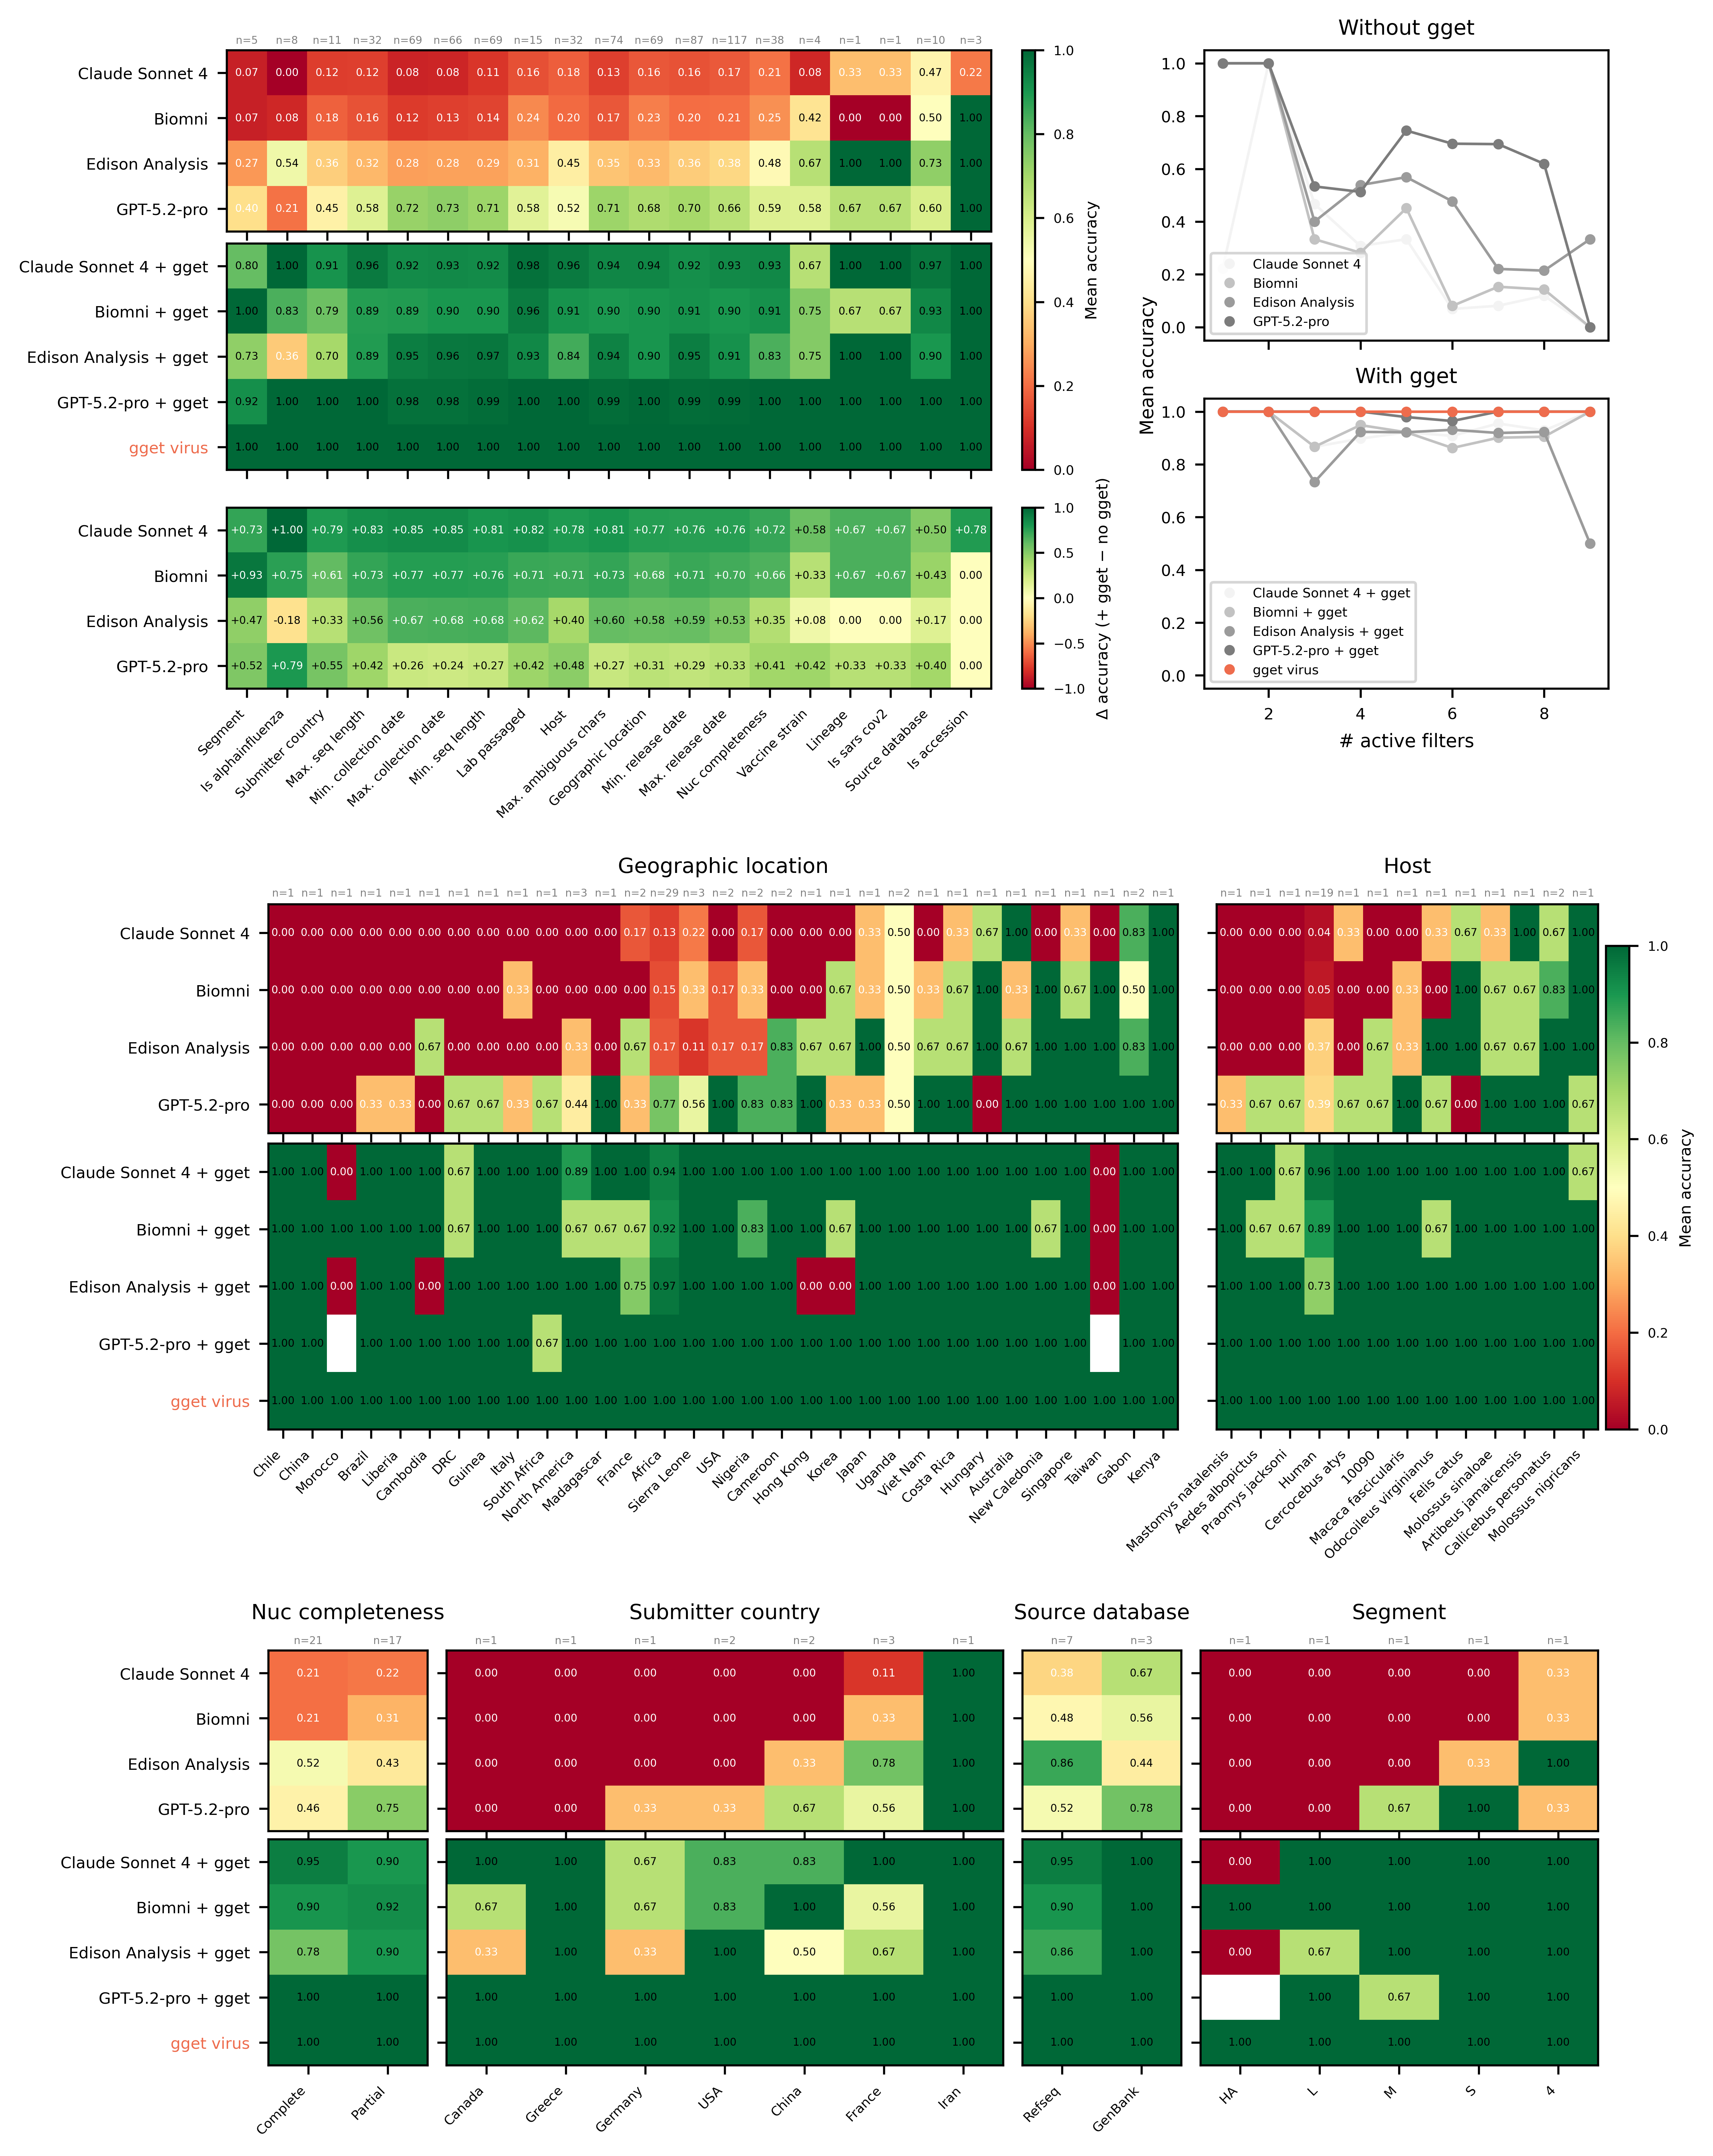

In [20]:
# === Combined supplementary figure (A4 page) ===

CATEGORICAL_FILTERS = [
    "geographic_location", "host", "nuc_completeness", "submitter_country",
    "source_database", "segment",
]

def cap_first(s):
    """Capitalize first letter, keep rest unchanged."""
    return s[0].upper() + s[1:] if s else s

# Precompute categorical filter data
cat_data = {}
for col in CATEGORICAL_FILTERS:
    unique_vals = sorted(configs[col].dropna().unique(), key=lambda x: cap_first(str(x)))
    if len(unique_vals) < 2:
        continue
    display_labels = [cap_first(str(v)) for v in unique_vals]
    val_acc = {name: [] for name in TECHNOLOGIES}
    n_per_val = []
    for val in unique_vals:
        qids = set(configs[configs[col] == val]["query_id"].tolist())
        n_per_val.append(len(qids))
        for name in TECHNOLOGIES:
            qid_acc = tech_accuracy.get(name, {})
            accs = [qid_acc[qid] for qid in qids if qid in qid_acc]
            val_acc[name].append(np.nanmean(accs) if accs else np.nan)
    display_labels = ["DRC" if v == "Democratic Republic of the Congo" else v for v in display_labels]
    cat_data[col] = {
        "vals": display_labels,
        "val_acc": val_acc,
        "n_per_val": n_per_val,
    }

# Sort each categorical filter's values by mean no-gget accuracy (worst to best)
for col in list(cat_data.keys()):
    cd = cat_data[col]
    nogget_accs = []
    for j in range(len(cd["vals"])):
        accs = [cd["val_acc"][name][j] for name in left_tech if name in cd["val_acc"]]
        nogget_accs.append(np.nanmean(accs))
    cat_sort_idx = sorted(range(len(cd["vals"])), key=lambda i: nogget_accs[i])
    cd["vals"] = [cd["vals"][i] for i in cat_sort_idx]
    cd["n_per_val"] = [cd["n_per_val"][i] for i in cat_sort_idx]
    for name in TECHNOLOGIES:
        if name in cd["val_acc"]:
            cd["val_acc"][name] = [cd["val_acc"][name][i] for i in cat_sort_idx]

HEATMAP_NUM_FS = 4  # fontsize for numbers inside heatmaps

# ── Helper: draw split heatmap on pre-created axes pair ──
def draw_split_heatmap(ax_top, ax_bot, matrix_left, matrix_right, col_labels,
                       title, n_per_col, show_yticklabels=True,
                       show_xticklabels=True, vmin=0, vmax=1, cmap="RdYlGn",
                       fmt=".2f", text_thresh=0.4):
    im0 = ax_top.imshow(matrix_left, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    im1 = ax_bot.imshow(matrix_right, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    for mat, ax in [(matrix_left, ax_top), (matrix_right, ax_bot)]:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                if np.isnan(val):
                    continue
                tc = "white" if val < text_thresh else "black"
                ax.text(j, i, f"{val:{fmt}}", ha="center", va="center",
                        fontsize=HEATMAP_NUM_FS, color=tc)

    ax_top.set_yticks(range(n_left))
    ax_bot.set_yticks(range(n_right))
    if show_yticklabels:
        ax_top.set_yticklabels(left_tech, fontsize=6)
        ax_bot.set_yticklabels(right_tech, fontsize=6)
        for label in ax_bot.get_yticklabels():
            if "gget virus" == label.get_text():
                label.set_color(COLORS["gget virus"])
    else:
        ax_top.set_yticklabels([])
        ax_bot.set_yticklabels([])

    ax_top.set_xticks(range(len(col_labels)))
    ax_top.set_xticklabels([])
    ax_top.tick_params(axis='x', bottom=True, top=False, labelbottom=False)
    ax_bot.set_xticks(range(len(col_labels)))
    if show_xticklabels:
        ax_bot.set_xticklabels(col_labels, fontsize=5, rotation=45, ha="right")
    else:
        ax_bot.set_xticklabels([])

    ax_top.set_title(title, fontsize=8, pad=12)

    if n_per_col is not None:
        for j, nq in enumerate(n_per_col):
            ax_top.text(j, -0.6, f"n={nq}", ha="center", va="bottom",
                        fontsize=4, color="gray")

    return im1

# ── Helper: draw A (mean accuracy split) + B (gget delta, single) with shared x-axis ──
def draw_stacked_heatmaps_shared_x(subfig, mat_a_left, mat_a_right, mat_b_delta,
                                    col_labels, n_per_col, delta_row_labels):
    n_delta = mat_b_delta.shape[0]
    gs = subfig.add_gridspec(
        4, 2,
        width_ratios=[30, 0.5],
        height_ratios=[n_left, n_right, 0.3, n_delta],
        wspace=0.08, hspace=0.08,
    )

    # Panel A: mean accuracy (split top/bottom)
    ax_a0 = subfig.add_subplot(gs[0, 0])
    ax_a1 = subfig.add_subplot(gs[1, 0], sharex=ax_a0)
    ax_cb_a = subfig.add_subplot(gs[0:2, 1])

    im_a0 = ax_a0.imshow(mat_a_left, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
    im_a1 = ax_a1.imshow(mat_a_right, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

    for mat, ax in [(mat_a_left, ax_a0), (mat_a_right, ax_a1)]:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                if np.isnan(val):
                    continue
                tc = "white" if val < 0.4 else "black"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=HEATMAP_NUM_FS, color=tc)

    # Panel B: gget delta (single heatmap)
    ax_b = subfig.add_subplot(gs[3, 0], sharex=ax_a0)
    ax_cb_b = subfig.add_subplot(gs[3, 1])

    im_b = ax_b.imshow(mat_b_delta, aspect="auto", cmap="RdYlGn", vmin=-1, vmax=1)

    for i in range(mat_b_delta.shape[0]):
        for j in range(mat_b_delta.shape[1]):
            val = mat_b_delta[i, j]
            if np.isnan(val):
                continue
            tc = "white" if abs(val) > 0.6 else "black"
            sign = "+" if val > 0 else ""
            ax_b.text(j, i, f"{sign}{val:.2f}", ha="center", va="center",
                      fontsize=HEATMAP_NUM_FS, color=tc)

    # Y-tick labels
    ax_a0.set_yticks(range(n_left))
    ax_a0.set_yticklabels(left_tech, fontsize=6)
    ax_a1.set_yticks(range(n_right))
    ax_a1.set_yticklabels(right_tech, fontsize=6)
    for label in ax_a1.get_yticklabels():
        if "gget virus" == label.get_text():
            label.set_color(COLORS["gget virus"])

    ax_b.set_yticks(range(n_delta))
    ax_b.set_yticklabels(delta_row_labels, fontsize=6)

    # X-tick labels: only on bottom-most axis
    for ax in [ax_a0, ax_a1]:
        ax.set_xticks(range(len(col_labels)))
        ax.set_xticklabels([])
        ax.tick_params(axis='x', bottom=True, top=False, labelbottom=False)

    ax_b.set_xticks(range(len(col_labels)))
    ax_b.set_xticklabels(col_labels, fontsize=5, rotation=45, ha="right")

    # n= annotations above panel A
    for j, nq in enumerate(n_per_col):
        ax_a0.text(j, -0.6, f"n={nq}", ha="center", va="bottom", fontsize=4, color="gray")

    # Colorbar A
    cb_a = subfig.colorbar(im_a1, cax=ax_cb_a, orientation="vertical")
    ax_cb_a.yaxis.set_label_position('right')
    ax_cb_a.tick_params(labelsize=5, left=False, right=True, labelleft=False, labelright=True)
    ax_cb_a.set_ylabel("Mean accuracy", fontsize=6)
    for spine in ["top", "bottom", "left"]:
        ax_cb_a.spines[spine].set_visible(False)

    # Colorbar B
    cb_b = subfig.colorbar(im_b, cax=ax_cb_b, orientation="vertical")
    ax_cb_b.yaxis.set_label_position('right')
    ax_cb_b.tick_params(labelsize=5, left=False, right=True, labelleft=False, labelright=True)
    ax_cb_b.set_ylabel("Δ accuracy (+ gget − no gget)", fontsize=6)
    for spine in ["top", "bottom", "left"]:
        ax_cb_b.spines[spine].set_visible(False)

# ── Helper: line plots ──
def draw_single_nfilters(ax, tech_list, title):
    for name in tech_list:
        qid_acc = tech_accuracy.get(name, {})
        nf_acc = {}
        for _, row in configs.iterrows():
            qid = row["query_id"]
            nf = row["n_filters"]
            if qid in qid_acc:
                nf_acc.setdefault(nf, []).append(qid_acc[qid])
        nfs = sorted(nf_acc.keys())
        means = [np.nanmean(nf_acc[nf]) for nf in nfs]
        facecolor = COLORS[name]
        edgecolor = COLORS[name]
        ax.plot(nfs, means, '-', color=edgecolor, lw=1)
        ax.plot(nfs, means, 'o', markerfacecolor=facecolor, markeredgecolor=edgecolor,
                markersize=3, label=name)
    ax.set_xlabel("# active filters", fontsize=7)
    ax.set_title(title, fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=5, loc="lower left")

# ═══════ Build the combined figure ═══════
fig = plt.figure(figsize=(8.27, 11.69), dpi=300)

outer_gs = fig.add_gridspec(2, 2, width_ratios=[2, 1],
                            height_ratios=[3, 5], hspace=0.25, wspace=0.2,
                            left=0.0, right=1.0, top=1.0, bottom=0.0)

# ── Top-left: (A) mean accuracy + (B) gget delta ──
subfig_ab = fig.add_subfigure(outer_gs[0, 0])

left_m = np.array([filter_acc_present[name] for name in left_tech])
right_m = np.array([filter_acc_present[name] for name in right_tech])

# Compute gget delta: (with_gget - without_gget) per LLM base
gget_delta = np.array([
    np.array(filter_acc_present[name + " + gget"]) - np.array(filter_acc_present[name])
    for name in llm_bases
])

# Sort filters by mean no-gget accuracy (worst to best)
mean_nogget_acc = np.nanmean(left_m, axis=0)
filter_sort_idx = sorted(range(len(filter_labels)), key=lambda i: mean_nogget_acc[i])
sorted_filter_labels = [filter_labels[i] for i in filter_sort_idx]
sorted_n_queries = [n_queries_per_filter[i] for i in filter_sort_idx]
left_m = left_m[:, filter_sort_idx]
right_m = right_m[:, filter_sort_idx]
gget_delta = gget_delta[:, filter_sort_idx]

draw_stacked_heatmaps_shared_x(
    subfig_ab, left_m, right_m, gget_delta,
    sorted_filter_labels, sorted_n_queries, llm_bases
)

# ── Top-right: (C) Line plots ──
subfig_lines = fig.add_subfigure(outer_gs[0, 1])
ax_lines = subfig_lines.subplots(2, 1, sharex=True)
draw_single_nfilters(ax_lines[0], left_tech, "Without gget")
draw_single_nfilters(ax_lines[1], right_tech, "With gget")
ax_lines[0].set_xlabel("")
subfig_lines.subplots_adjust(hspace=0.2)
subfig_lines.supylabel("Mean accuracy", fontsize=7, x=0)

# ── Bottom half: D-I using two gridspecs with shared left/right ──
subfig_lower = fig.add_subfigure(outer_gs[1, :])

n_geo = len(cat_data["geographic_location"]["vals"])
n_host = len(cat_data["host"]["vals"])
small_cats = ["nuc_completeness", "submitter_country", "source_database", "segment"]
small_cats = [c for c in small_cats if c in cat_data]
n_small = [max(len(cat_data[c]["vals"]), 2) for c in small_cats]

# Shared horizontal bounds → guarantees left/right alignment
GS_L = 0.11     # left edge (room for y-labels)
GS_R = 0.96     # right edge of heatmaps
CB_L = 0.965    # colorbar left
CB_W = 0.015    # colorbar width
WS   = 0.06    # wspace between panels within a row

# Row 0: D + E  (top portion of subfig_lower)
gs0 = subfig_lower.add_gridspec(
    2, 2,
    width_ratios=[n_geo, n_host],
    height_ratios=[n_left, n_right],
    left=GS_L, right=GS_R,
    top=0.91, bottom=0.53,
    hspace=0.04, wspace=WS,
)

# Row 1: F–I  (bottom portion)
gs1 = subfig_lower.add_gridspec(
    2, len(small_cats),
    width_ratios=n_small,
    height_ratios=[n_left, n_right],
    left=GS_L, right=GS_R,
    top=0.37, bottom=0.07,
    hspace=0.04, wspace=WS,
)

# ── Draw D (geographic_location) ──
cd_geo = cat_data["geographic_location"]
lm_geo = np.array([cd_geo["val_acc"][name] for name in left_tech])
rm_geo = np.array([cd_geo["val_acc"][name] for name in right_tech])
ax_d0 = subfig_lower.add_subplot(gs0[0, 0])
ax_d1 = subfig_lower.add_subplot(gs0[1, 0], sharex=ax_d0)
draw_split_heatmap(ax_d0, ax_d1, lm_geo, rm_geo, cd_geo["vals"],
                   "Geographic location", cd_geo["n_per_val"],
                   show_yticklabels=True)

# ── Draw E (host) ──
cd_host = cat_data["host"]
lm_host = np.array([cd_host["val_acc"][name] for name in left_tech])
rm_host = np.array([cd_host["val_acc"][name] for name in right_tech])
ax_e0 = subfig_lower.add_subplot(gs0[0, 1])
ax_e1 = subfig_lower.add_subplot(gs0[1, 1], sharex=ax_e0)
im_e = draw_split_heatmap(ax_e0, ax_e1, lm_host, rm_host, cd_host["vals"],
                           "Host", cd_host["n_per_val"],
                           show_yticklabels=False)

# Colorbar for D+E row
ax_cb = subfig_lower.add_axes([CB_L, 0.53, CB_W, 0.88 - 0.53])
cb = subfig_lower.colorbar(im_e, cax=ax_cb, orientation="vertical")
ax_cb.yaxis.set_label_position('right')
ax_cb.tick_params(labelsize=5, left=False, right=True, labelleft=False, labelright=True)
ax_cb.set_ylabel("Mean accuracy", fontsize=6)
for spine in ["top", "bottom", "left"]:
    ax_cb.spines[spine].set_visible(False)

# ── Draw F–I (small categorical filters) ──
for idx, col in enumerate(small_cats):
    cd = cat_data[col]
    lm = np.array([cd["val_acc"][name] for name in left_tech])
    rm = np.array([cd["val_acc"][name] for name in right_tech])
    ax_top = subfig_lower.add_subplot(gs1[0, idx])
    ax_bot = subfig_lower.add_subplot(gs1[1, idx], sharex=ax_top)
    draw_split_heatmap(ax_top, ax_bot, lm, rm, cd["vals"],
                       f"{col.replace('_', ' ').capitalize()}",
                       cd["n_per_val"],
                       show_yticklabels=(idx == 0))

fig.savefig("../figures/filter_heatmaps.png", dpi=300, bbox_inches="tight")
# fig.savefig("../figures/filter_heatmaps.pdf", bbox_inches="tight")
# plt.tight_layout()
plt.show()